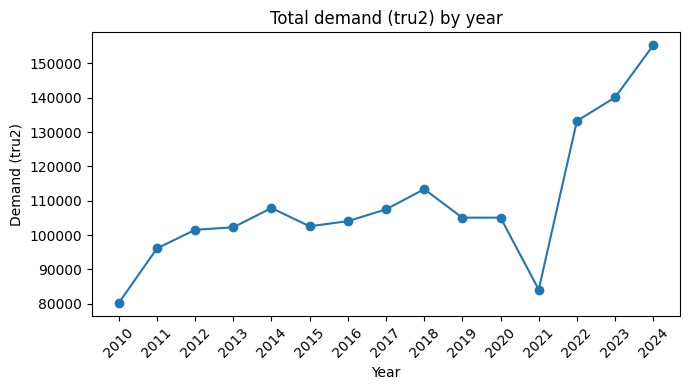

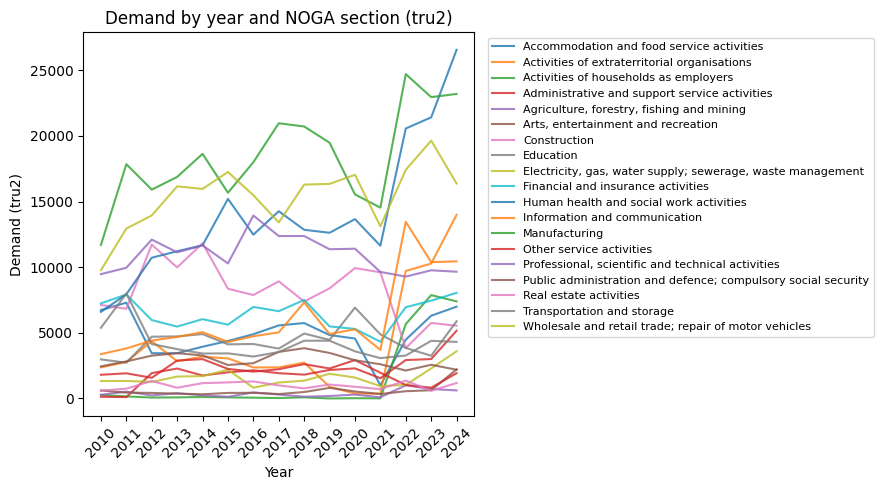

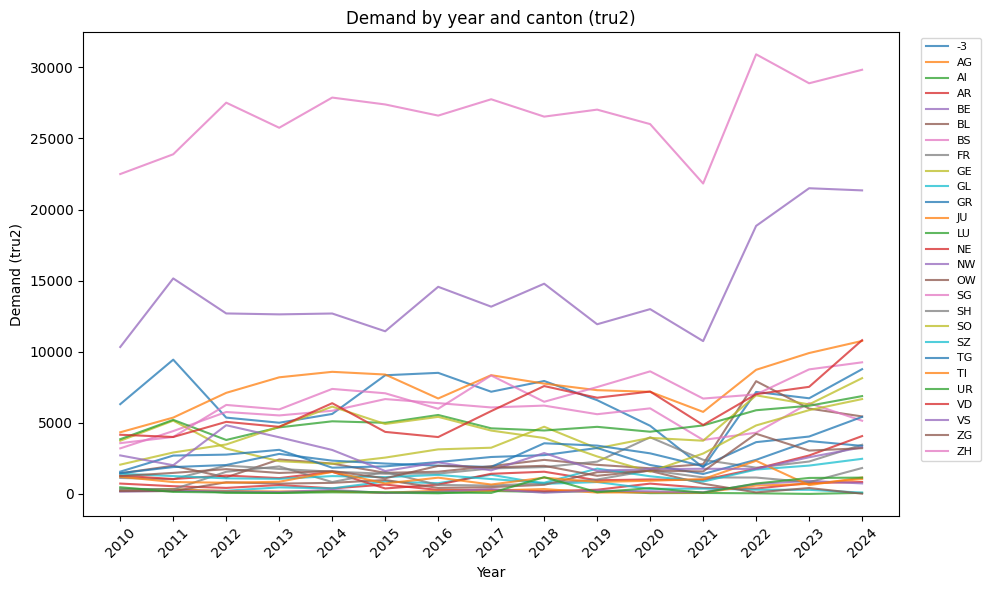

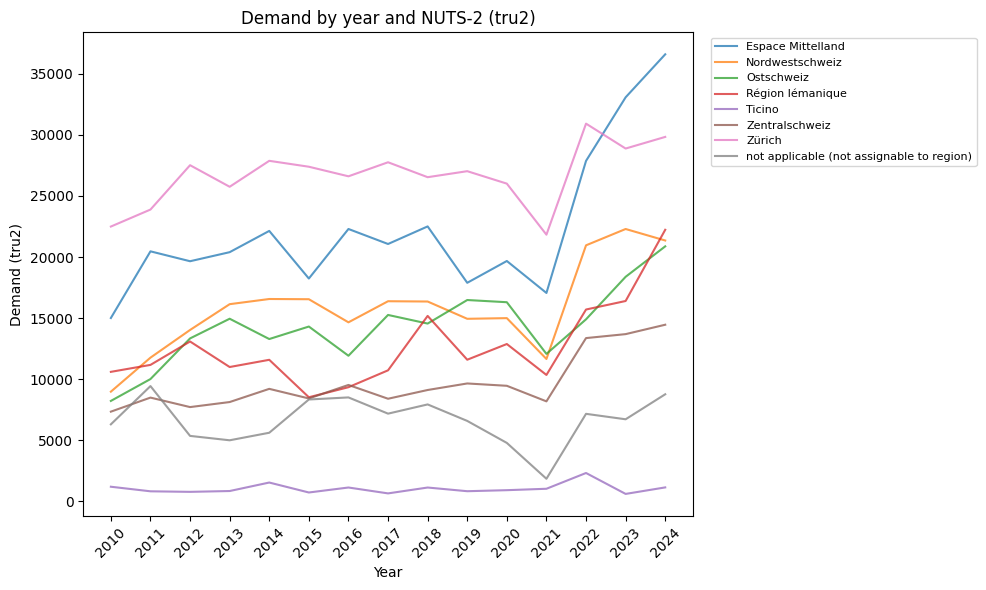

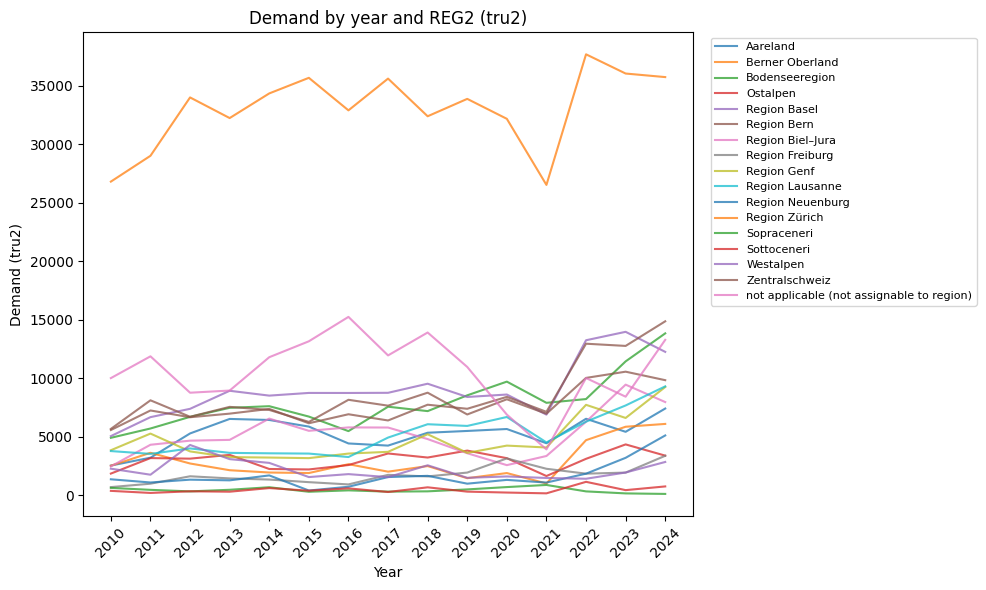

In [58]:
# === Demand over time (overall, NOGA section, canton) ===
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def _load_df_if_needed():
    global _df
    if '_df' in globals():
        return _df
    # find repo root
    def _find_root():
        if '__file__' in globals():
            return Path(__file__).resolve().parents[2]
        cwd = Path.cwd().resolve()
        for p in [cwd] + list(cwd.parents):
            if (p / 'Results Datasets' / 'final_analysis_dataset.parquet').exists():
                return p
        return cwd
    ROOT = _find_root()
    data_path = ROOT / 'Results Datasets' / 'final_analysis_dataset.parquet'
    if not data_path.exists():
        raise FileNotFoundError(data_path)
    _df = pd.read_parquet(data_path)
    _df = _df[(_df['adve_time_year'] >= 2010) & (_df['adve_time_year'] <= 2024)].copy()
    return _df

df = _load_df_if_needed()

# --- Ensure region labels (NUTS-2 / REG2) from codebook for this cell
import re

_def_root = None
for p in [Path.cwd().resolve()] + list(Path.cwd().resolve().parents):
    if (p / 'scripts' / 'Analysis' / 'Final dataset field descriptions.md').exists():
        _def_root = p
        break
if _def_root is None:
    _def_root = Path.cwd().resolve()
_md_path = _def_root / 'scripts' / 'Analysis' / 'Final dataset field descriptions.md'


def _load_codebook_labels_simple(var_name):
    if not _md_path.exists():
        return {}
    text = _md_path.read_text(encoding='utf-8')
    pat = re.compile(rf"### `{re.escape(var_name)}`(.*?)^### `", re.S | re.M)
    m = pat.search(text)
    if not m:
        return {}
    section = m.group(1)
    label_pat = re.compile(r"- `([^`]+)` =\s*([^\n]+)")
    labels = {}
    for code_raw, label in label_pat.findall(section):
        code_raw = code_raw.strip()
        if code_raw.upper() == 'NA':
            mcode = re.match(r"(-?\d+)\s*(.*)", label.strip())
            if not mcode:
                continue
            code = int(mcode.group(1))
            label_text = mcode.group(2).strip()
        else:
            try:
                code = int(code_raw)
            except ValueError:
                continue
            label_text = label.strip()
            mlabel = re.match(r"\d+\s*(.*)", label_text)
            if mlabel:
                label_text = mlabel.group(1).strip()
        labels[code] = label_text
    return labels

for _var, _label_col in [('loca_regi_nuts', 'loca_regi_nuts_label'), ('loca_labo_reg2', 'loca_labo_reg2_label')]:
    if _var in df.columns:
        _map = _load_codebook_labels_simple(_var)
        _raw = pd.to_numeric(df[_var], errors='coerce')
        df[_label_col] = _raw.map(_map)
        df[_label_col] = df[_label_col].fillna('Unknown').astype('string')

# 1) Total demand per year
year_demand = df.groupby('adve_time_year')['srvy_wght_tru2'].sum().reset_index()
plt.figure(figsize=(7,4))
plt.plot(year_demand['adve_time_year'], year_demand['srvy_wght_tru2'], marker='o')
plt.title('Total demand (tru2) by year')
plt.xlabel('Year')
plt.ylabel('Demand (tru2)')
plt.xticks(year_demand['adve_time_year'], rotation=45)
plt.tight_layout()
plt.show()

# 2) Demand by year and NOGA section
noga_col = None
if 'industry_section_label' in df.columns:
    noga_col = 'industry_section_label'
elif 'noga_section_label' in df.columns:
    noga_col = 'noga_section_label'

if noga_col:
    sec = (
        df.assign(_noga=df[noga_col].fillna('Unknown').astype(str))
          .groupby(['adve_time_year', '_noga'])['srvy_wght_tru2'].sum()
          .unstack(fill_value=0)
    )
    plt.figure(figsize=(9,5))
    for col in sec.columns:
        plt.plot(sec.index, sec[col], label=col, alpha=0.8)
    plt.title('Demand by year and NOGA section (tru2)')
    plt.xlabel('Year')
    plt.ylabel('Demand (tru2)')
    plt.xticks(sec.index, rotation=45)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('NOGA section label column not found in dataset.')

# 3) Demand by year and canton
canton_col = 'loca_regi_kant_label' if 'loca_regi_kant_label' in df.columns else 'loca_regi_kant'
cant = (
    df.assign(_cant=df[canton_col].fillna('Unknown').astype(str))
      .groupby(['adve_time_year', '_cant'])['srvy_wght_tru2'].sum()
      .unstack(fill_value=0)
)
plt.figure(figsize=(10,6))
for col in cant.columns:
    plt.plot(cant.index, cant[col], label=col, alpha=0.75)
plt.title('Demand by year and canton (tru2)')
plt.xlabel('Year')
plt.ylabel('Demand (tru2)')
plt.xticks(cant.index, rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# --- Demand by year and NUTS-2 ---
nuts_col = 'loca_regi_nuts_label' if 'loca_regi_nuts_label' in df.columns else ('loca_regi_nuts' if 'loca_regi_nuts' in df.columns else None)
if nuts_col:
    nuts = (
        df.assign(_nuts=df[nuts_col].fillna('Unknown').astype(str))
          .groupby(['adve_time_year', '_nuts'])['srvy_wght_tru2'].sum()
          .unstack(fill_value=0)
    )
    plt.figure(figsize=(10,6))
    for col in nuts.columns:
        plt.plot(nuts.index, nuts[col], label=col, alpha=0.75)
    plt.title('Demand by year and NUTS-2 (tru2)')
    plt.xlabel('Year')
    plt.ylabel('Demand (tru2)')
    plt.xticks(nuts.index, rotation=45)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('NUTS-2 column not found.')

# --- Demand by year and REG2 ---
reg2_col = 'loca_labo_reg2_label' if 'loca_labo_reg2_label' in df.columns else ('loca_labo_reg2' if 'loca_labo_reg2' in df.columns else None)
if reg2_col:
    reg2 = (
        df.assign(_reg2=df[reg2_col].fillna('Unknown').astype(str))
          .groupby(['adve_time_year', '_reg2'])['srvy_wght_tru2'].sum()
          .unstack(fill_value=0)
    )
    plt.figure(figsize=(10,6))
    for col in reg2.columns:
        plt.plot(reg2.index, reg2[col], label=col, alpha=0.75)
    plt.title('Demand by year and REG2 (tru2)')
    plt.xlabel('Year')
    plt.ylabel('Demand (tru2)')
    plt.xticks(reg2.index, rotation=45)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('REG2 column not found.')


# Phase 1 — Demand landscape (non‑exposure visuals)

This notebook reuses the existing demand‑only composition charts (no exposure metrics).
Outputs are saved under Results Datasets/analysis/phase1_demand/.


In [59]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Paths
def find_root():
    if "__file__" in globals():
        return Path(__file__).resolve().parents[2]
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / "Results Datasets" / "final_analysis_dataset.parquet").exists():
            return p
    return cwd
ROOT = find_root()
DATA_PATH = ROOT / "Results Datasets" / "final_analysis_dataset.parquet"
OUT_ROOT = ROOT / "Results Datasets" / "analysis" / "phase1_demand"
OUT_TABLES = OUT_ROOT / "tables"
OUT_VIS = OUT_ROOT / "visuals"
for d in [OUT_ROOT, OUT_TABLES, OUT_VIS]:
    d.mkdir(parents=True, exist_ok=True)

# --- Load data
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)
_df = pd.read_parquet(DATA_PATH)
_df = _df[(_df["adve_time_year"] >= 2010) & (_df["adve_time_year"] <= 2024)].copy()

# --- Region label mapping for NUTS-2 and REG2 (from codebook)
import re

def _load_codebook_labels(var_name):
    md_path = ROOT / 'scripts' / 'Analysis' / 'Final dataset field descriptions.md'
    if not md_path.exists():
        return {}
    text = md_path.read_text(encoding='utf-8')
    pat = re.compile(rf"### `{re.escape(var_name)}`(.*?)^### `", re.S | re.M)
    m = pat.search(text)
    if not m:
        return {}
    section = m.group(1)
    label_pat = re.compile(r"- `([^`]+)` =\s*([^\n]+)")
    labels = {}
    for code_raw, label in label_pat.findall(section):
        code_raw = code_raw.strip()
        if code_raw.upper() == 'NA':
            mcode = re.match(r"(-?\d+)\s*(.*)", label.strip())
            if not mcode:
                continue
            code = int(mcode.group(1))
            label_text = mcode.group(2).strip()
        else:
            try:
                code = int(code_raw)
            except ValueError:
                continue
            label_text = label.strip()
            mlabel = re.match(r"\d+\s*(.*)", label_text)
            if mlabel:
                label_text = mlabel.group(1).strip()
        labels[code] = label_text
    return labels

# Create label columns if not already present
if 'loca_regi_nuts' in _df.columns:
    nuts_map = _load_codebook_labels('loca_regi_nuts')
    _df['loca_regi_nuts_label'] = pd.to_numeric(_df['loca_regi_nuts'], errors='coerce').map(nuts_map)
    _df['loca_regi_nuts_label'] = _df['loca_regi_nuts_label'].fillna('Unknown').astype('string')

if 'loca_labo_reg2' in _df.columns:
    reg2_map = _load_codebook_labels('loca_labo_reg2')
    _df['loca_labo_reg2_label'] = pd.to_numeric(_df['loca_labo_reg2'], errors='coerce').map(reg2_map)
    _df['loca_labo_reg2_label'] = _df['loca_labo_reg2_label'].fillna('Unknown').astype('string')

# Ensure labels used by charts
if "comp_indu_noga_label" in _df.columns:
    _df["comp_indu_noga_label"] = _df["comp_indu_noga_label"].astype("string")
if "industry_section_label" in _df.columns:
    _df["industry_section_label"] = _df["industry_section_label"].astype("string")
if "occu_isco1_label" in _df.columns:
    _df["occu_isco1_label"] = _df["occu_isco1_label"].astype("string")
if "occu_isco2_label" in _df.columns:
    _df["occu_isco2_label"] = _df["occu_isco2_label"].astype("string")

# Canton labels (if already present, keep)
if "loca_regi_kant_label" in _df.columns:
    _df["loca_regi_kant_label"] = _df["loca_regi_kant_label"].astype("string")


# --- Core columns used later
region_col = "loca_regi_kant_label" if "loca_regi_kant_label" in _df.columns else "loca_regi_kant"


# Ensure canton labels are abbreviations (not numeric codes)
canton_map = {
    1:"ZH",2:"BE",3:"LU",4:"UR",5:"SZ",6:"OW",7:"NW",8:"GL",9:"ZG",
    10:"FR",11:"SO",12:"BS",13:"BL",14:"SH",15:"AR",16:"AI",17:"SG",
    18:"GR",19:"AG",20:"TG",21:"TI",22:"VD",23:"VS",24:"NE",25:"GE",26:"JU"
}

def _map_canton_label(val):
    if pd.isna(val):
        return "Unknown"
    s = str(val)
    if s.lower() == "unknown":
        return "Unknown"
    if s.isdigit():
        return canton_map.get(int(s), s)
    return s

if region_col == "loca_regi_kant":
    _df["loca_regi_kant_label"] = _df["loca_regi_kant"].apply(_map_canton_label).astype("string")
    region_col = "loca_regi_kant_label"
else:
    _df["loca_regi_kant_label"] = _df["loca_regi_kant_label"].apply(_map_canton_label).astype("string")
occ_exp_col = "occupation_exposure"
ind_exp_col = "industry_exposure_weighted"

# --- Weighted quantiles (tru2) for exposure segments

def weighted_quantile(values, weights, q):
    vals = pd.to_numeric(values, errors="coerce").to_numpy(dtype=float)
    wts = pd.to_numeric(weights, errors="coerce").to_numpy(dtype=float)
    mask = ~np.isnan(vals) & ~np.isnan(wts)
    if mask.sum() == 0:
        return np.nan
    vals = vals[mask]
    wts = wts[mask]
    order = np.argsort(vals)
    vals = vals[order]
    wts = wts[order]
    cum = np.cumsum(wts)
    total = cum[-1]
    return vals[np.searchsorted(cum, q * total)]

occ_p20 = weighted_quantile(_df[occ_exp_col], _df["srvy_wght_tru2"], 0.20)
occ_p40 = weighted_quantile(_df[occ_exp_col], _df["srvy_wght_tru2"], 0.40)
occ_p60 = weighted_quantile(_df[occ_exp_col], _df["srvy_wght_tru2"], 0.60)
occ_p80 = weighted_quantile(_df[occ_exp_col], _df["srvy_wght_tru2"], 0.80)
occ_p90 = weighted_quantile(_df[occ_exp_col], _df["srvy_wght_tru2"], 0.90)

ind_p20 = weighted_quantile(_df[ind_exp_col], _df["srvy_wght_tru2"], 0.20)
ind_p40 = weighted_quantile(_df[ind_exp_col], _df["srvy_wght_tru2"], 0.40)
ind_p60 = weighted_quantile(_df[ind_exp_col], _df["srvy_wght_tru2"], 0.60)
ind_p80 = weighted_quantile(_df[ind_exp_col], _df["srvy_wght_tru2"], 0.80)
ind_p90 = weighted_quantile(_df[ind_exp_col], _df["srvy_wght_tru2"], 0.90)

# --- Color helpers (shared across plots)
from matplotlib import cm

def _base_label(label):
    s = str(label)
    if " (exp=" in s:
        s = s.split(" (exp=")[0]
    return s

def _normalize_other(label, other_label="Other"):
    s = _base_label(label)
    if s.lower().startswith("other"):
        return other_label
    return s


def build_color_map(labels, other_label="Other"):
    base = list(cm.get_cmap("tab20").colors) + list(cm.get_cmap("tab20b").colors) + list(cm.get_cmap("tab20c").colors)
    def mute(rgb, alpha=0.7):
        r, g, b = rgb[:3]
        return (alpha*r + (1-alpha)*1.0, alpha*g + (1-alpha)*1.0, alpha*b + (1-alpha)*1.0, 1.0)
    muted = [mute(c) for c in base]
    cmap = {}
    i = 0
    for lab in labels:
        lab_norm = _normalize_other(lab, other_label=other_label)
        if lab_norm == other_label or lab_norm in cmap:
            continue
        cmap[lab_norm] = muted[i % len(muted)]
        i += 1
    cmap[other_label] = (0.85, 0.85, 0.85, 1.0)
    return cmap


def color_for_label(label, cmap, other_label="Other"):
    key = _normalize_other(label, other_label=other_label)
    return cmap.get(key, (0.85, 0.85, 0.85, 1.0))


def _ordered_labels_from_series(s):
    seen = set()
    out = []
    for lab in s.index:
        labn = _normalize_other(lab)
        if labn in seen:
            continue
        seen.add(labn)
        out.append(labn)
    return out

# Build color maps once per taxonomy (global ordering by tru2 share)
if "occu_isco1_label" in _df.columns:
    isco1_order = _df.groupby(_df["occu_isco1_label"].fillna("Unknown"))["srvy_wght_tru2"].sum().sort_values(ascending=False)
else:
    isco1_order = pd.Series(dtype=float)

if "occu_isco2_label" in _df.columns:
    isco2_order = _df.groupby(_df["occu_isco2_label"].fillna("Unknown"))["srvy_wght_tru2"].sum().sort_values(ascending=False)
else:
    isco2_order = pd.Series(dtype=float)

if "comp_indu_noga_label" in _df.columns:
    comp_noga_order = _df.groupby(_df["comp_indu_noga_label"].fillna("Unknown"))["srvy_wght_tru2"].sum().sort_values(ascending=False)
else:
    comp_noga_order = pd.Series(dtype=float)

if "industry_section_label" in _df.columns:
    noga_section_order = _df.groupby(_df["industry_section_label"].fillna("Unknown"))["srvy_wght_tru2"].sum().sort_values(ascending=False)
else:
    noga_section_order = pd.Series(dtype=float)

color_map_isco1 = build_color_map(_ordered_labels_from_series(isco1_order), other_label="Other")
color_map_isco2 = build_color_map(_ordered_labels_from_series(isco2_order), other_label="Other")
color_map_comp_noga = build_color_map(_ordered_labels_from_series(comp_noga_order), other_label="Other")
color_map_noga_section = build_color_map(_ordered_labels_from_series(noga_section_order), other_label="Other")


# Helper: drop non-finite values before plotting
def _finite_for_plot(df, x_col, y_col, y_positive=False):
    tmp = df.replace([np.inf, -np.inf], np.nan)
    tmp = tmp[tmp[x_col].notna() & tmp[y_col].notna()]
    if y_positive:
        tmp = tmp[tmp[y_col] > 0]
    return tmp


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/908158133.py:166: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = list(cm.get_cmap("tab20").colors) + list(cm.get_cmap("tab20b").colors) + list(cm.get_cmap("tab20c").colors)


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/4133112709.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


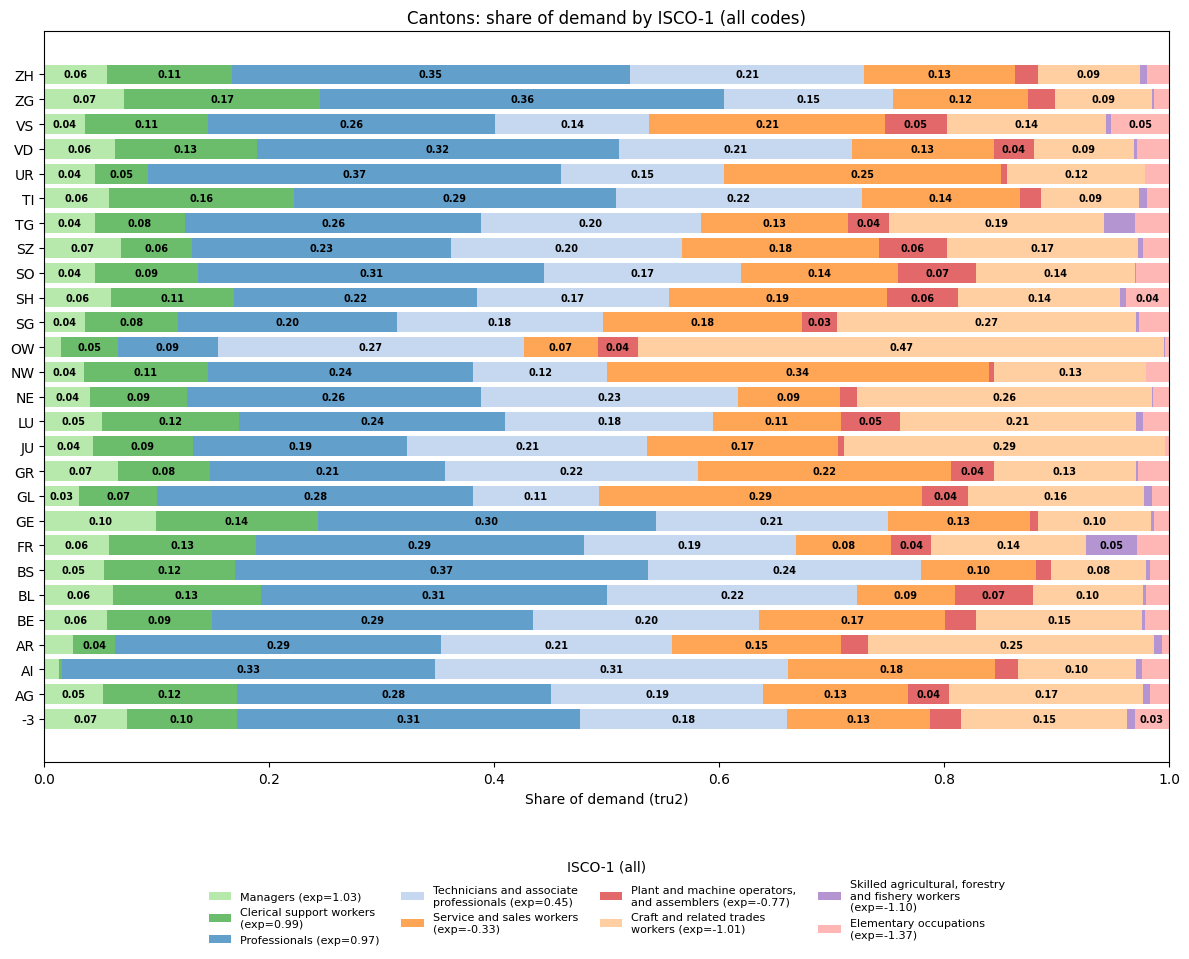

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_kanton_stack_isco1_share.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/4133112709.py:128: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


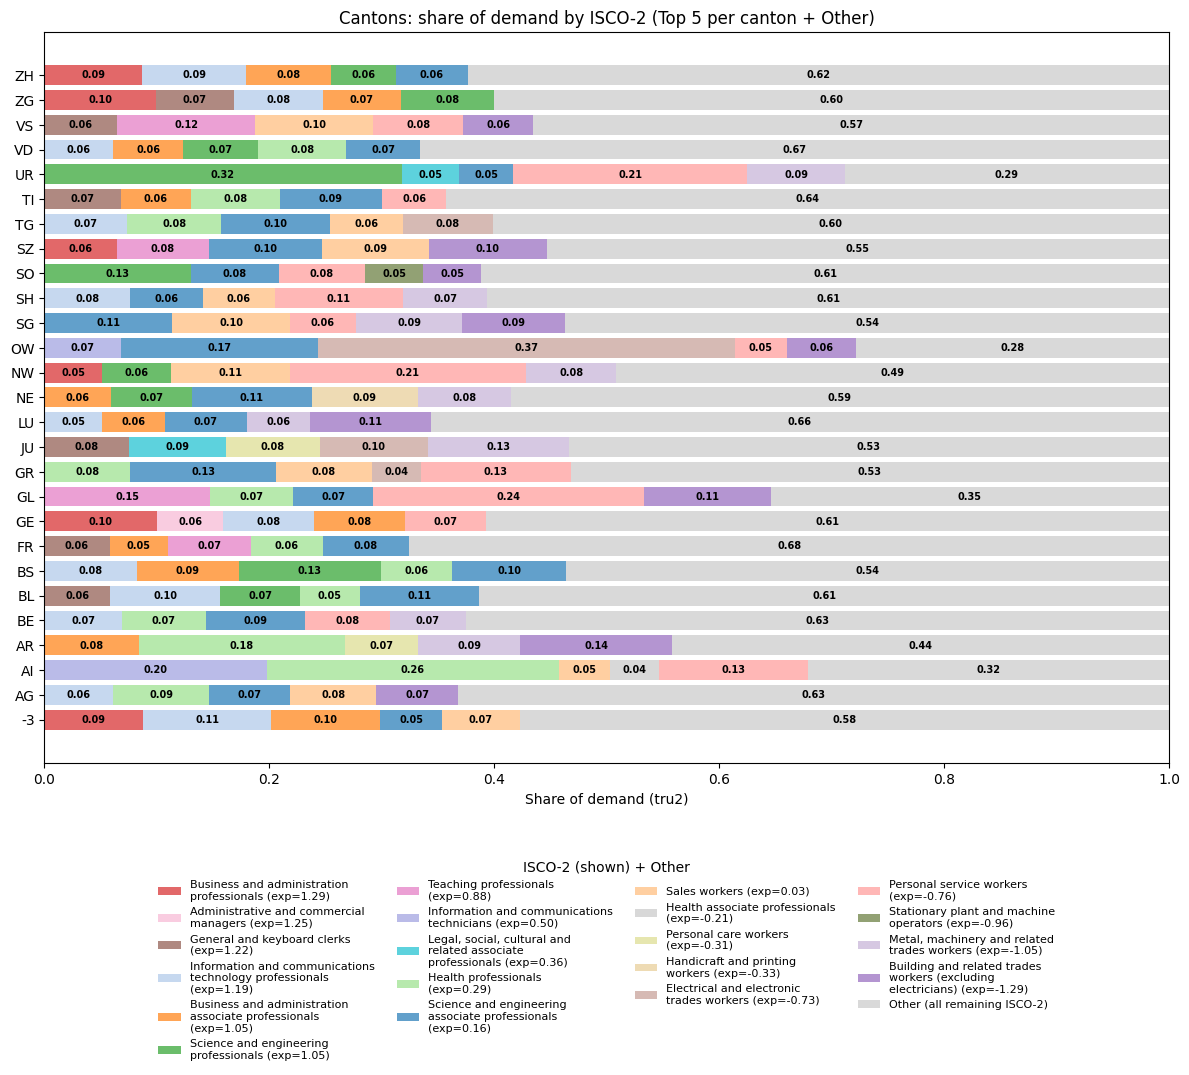

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_kanton_stack_isco2_share.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/4133112709.py:194: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


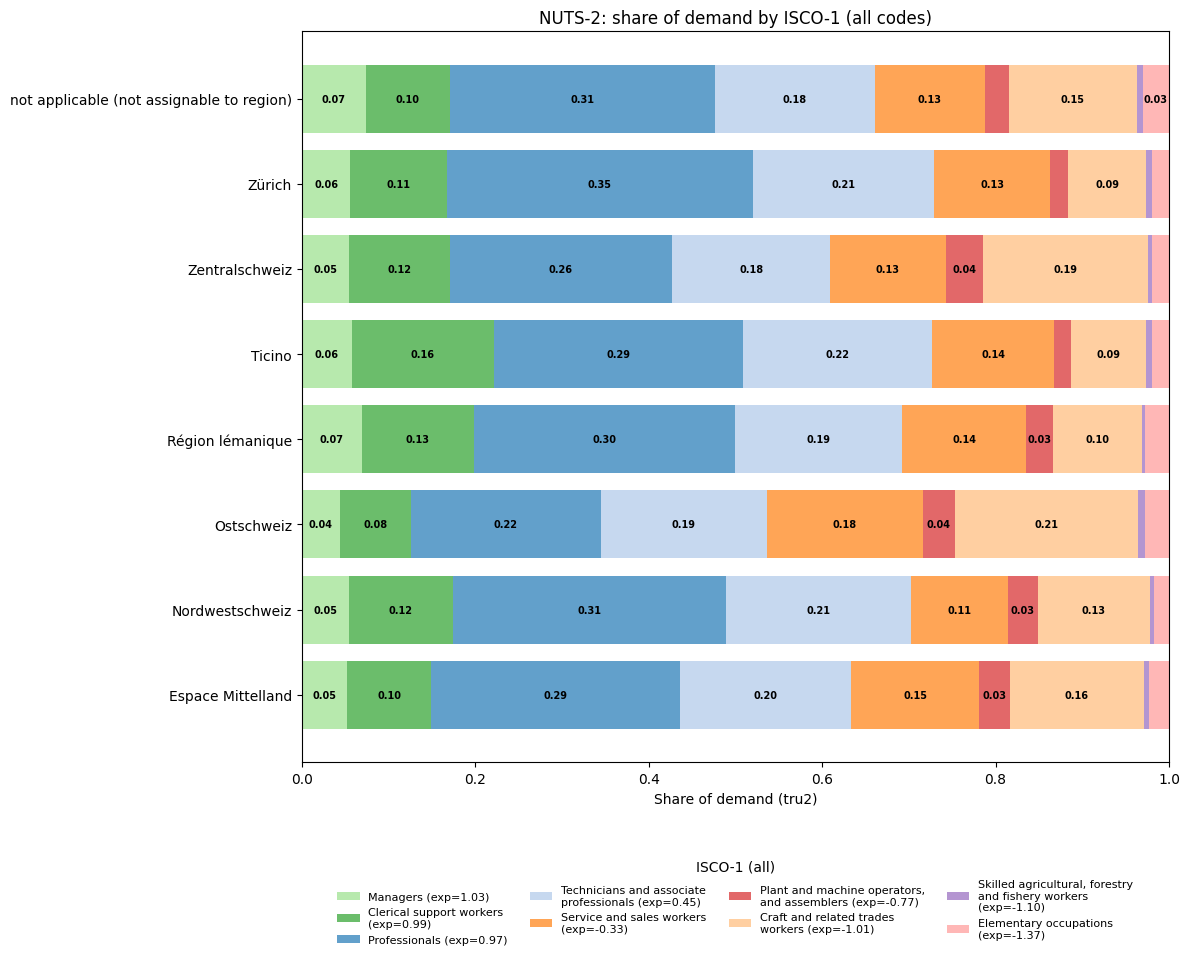

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_nuts-2_stack_isco1_share.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/4133112709.py:239: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


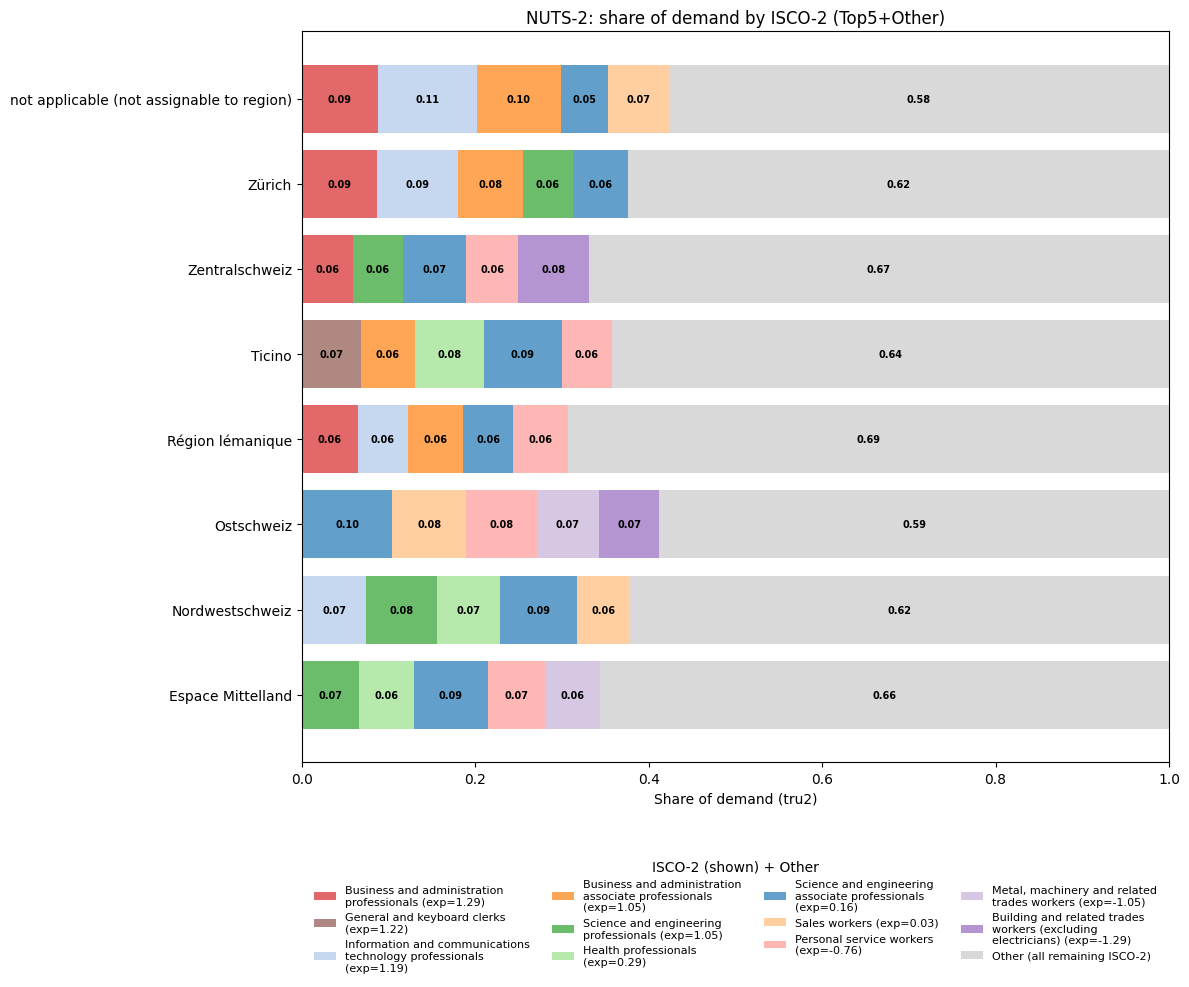

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_nuts-2_stack_isco2_share.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/4133112709.py:194: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


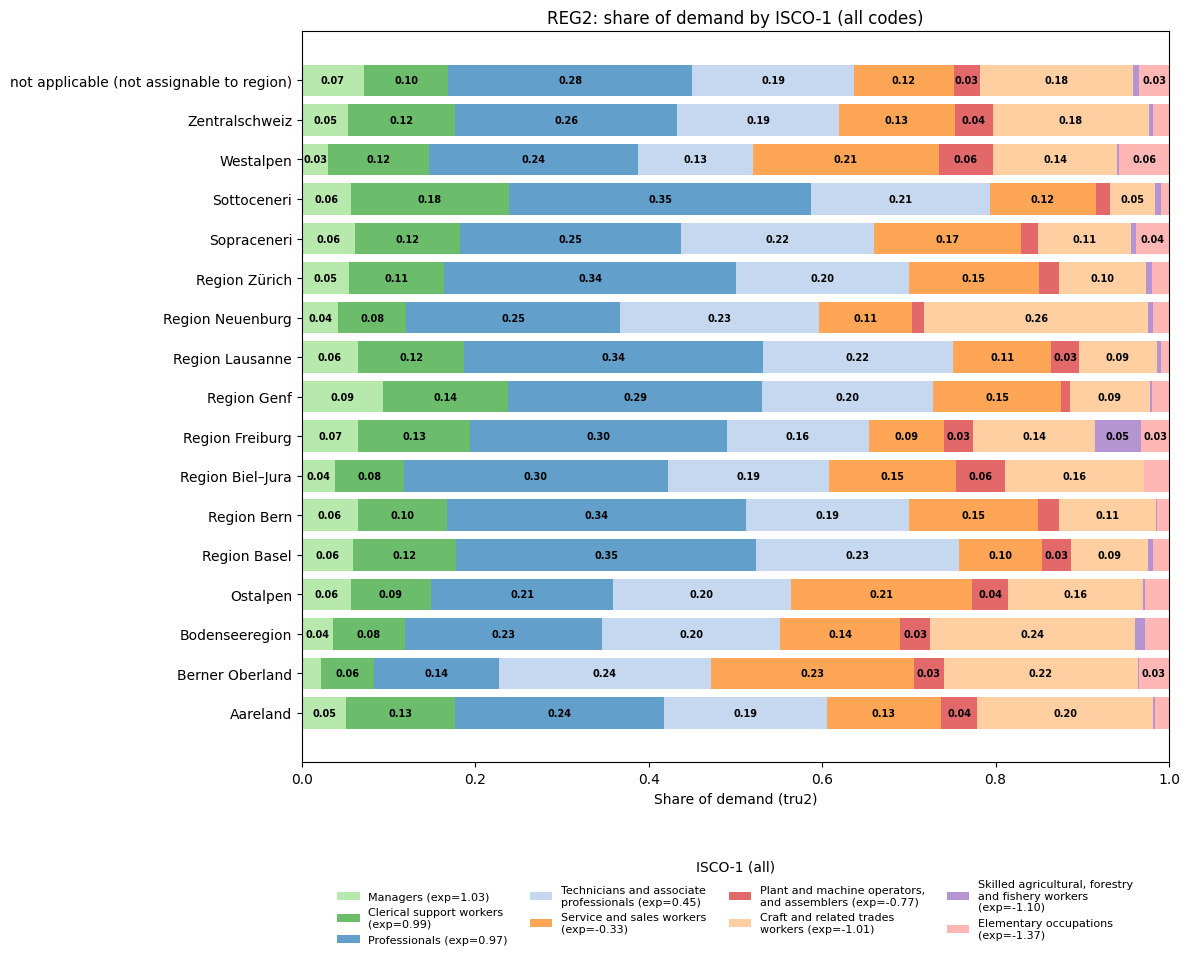

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_reg2_stack_isco1_share.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/4133112709.py:239: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


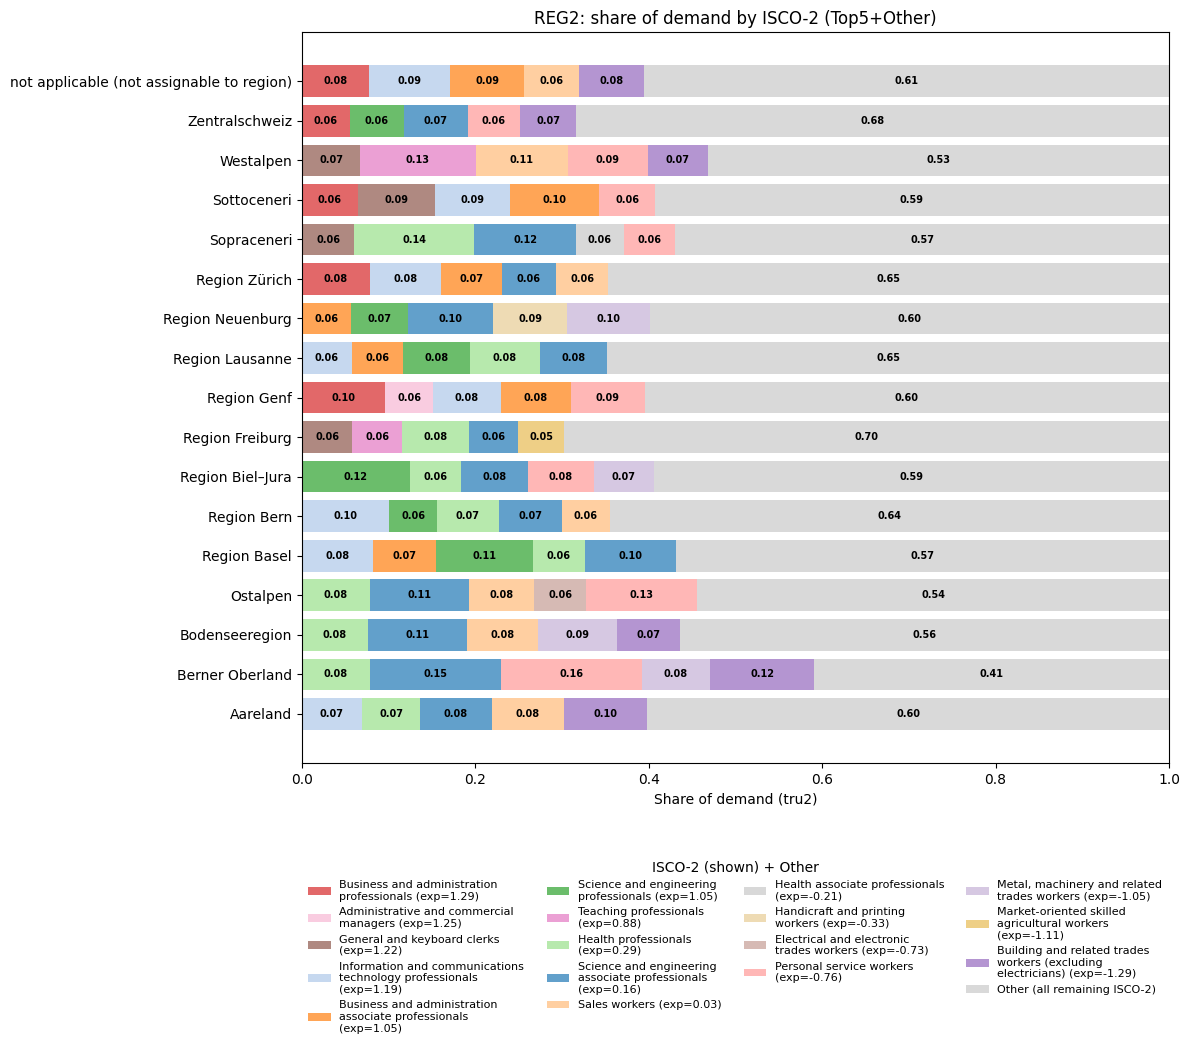

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_reg2_stack_isco2_share.png


In [60]:
# === Occupation exposure segments + ISCO shares by canton ===
import textwrap

# helper for labels with exposure in label
import re

def _exp_from_label(lbl):
    m = re.search(r"exp=([+-]?\d*\.?\d+)", str(lbl))
    return float(m.group(1)) if m else float("nan")


def _legend_below(ax, handles=None, labels=None, title=None, ncol=4):
    if handles is None or labels is None:
        handles, labels = ax.get_legend_handles_labels()
    labels = [textwrap.fill(str(l), width=30) for l in labels]
    leg = ax.legend(handles, labels, title=title, ncol=ncol,
                    loc="upper center", bbox_to_anchor=(0.5, -0.12),
                    frameon=False, fontsize=8)
    return leg

# Ensure color maps exist (in case cells run out of order)
if "color_map_isco1" not in globals():
    from matplotlib import cm
    def _base_label(label):
        s = str(label)
        if ' (exp=' in s:
            s = s.split(' (exp=')[0]
        return s
    def _normalize_other(label, other_label="Other"):
        s = _base_label(label)
        if s.lower().startswith('other'):
            return other_label
        return s
    def build_color_map(labels, other_label="Other"):
        base = list(cm.get_cmap("tab20").colors) + list(cm.get_cmap("tab20b").colors) + list(cm.get_cmap("tab20c").colors)
        def mute(rgb, alpha=0.7):
            r, g, b = rgb[:3]
            return (alpha*r + (1-alpha)*1.0, alpha*g + (1-alpha)*1.0, alpha*b + (1-alpha)*1.0, 1.0)
        muted = [mute(c) for c in base]
        cmap = {}
        i = 0
        for lab in labels:
            lab_norm = _normalize_other(lab, other_label=other_label)
            if lab_norm == other_label or lab_norm in cmap:
                continue
            cmap[lab_norm] = muted[i % len(muted)]
            i += 1
        cmap[other_label] = (0.85, 0.85, 0.85, 1.0)
        return cmap
    def color_for_label(label, cmap, other_label="Other"):
        key = _normalize_other(label, other_label=other_label)
        return cmap.get(key, (0.85,0.85,0.85,1.0))

    def _ordered_labels_from_series(s):
        seen=set(); out=[]
        for lab in s.index:
            labn=_normalize_other(lab)
            if labn in seen: continue
            seen.add(labn); out.append(labn)
        return out

    isco1_order = (_df.groupby(_df['occu_isco1_label'].fillna('Unknown'))['srvy_wght_tru2'].sum().sort_values(ascending=False))
    isco2_order = (_df.groupby(_df['occu_isco2_label'].fillna('Unknown'))['srvy_wght_tru2'].sum().sort_values(ascending=False))
    color_map_isco1 = build_color_map(_ordered_labels_from_series(isco1_order), other_label='Other')
    color_map_isco2 = build_color_map(_ordered_labels_from_series(isco2_order), other_label='Other')

# --- Plot: share of demand by ISCO-1 (all codes) ---
occ1_label = _df["occu_isco1_label"].fillna("Unknown")
occ1_exp_map = (
    _df.assign(_occ1=occ1_label)
       .groupby("_occ1", observed=True)
       .apply(lambda g: np.average(
           g.loc[g[occ_exp_col].notna(), occ_exp_col],
           weights=g.loc[g[occ_exp_col].notna(), "srvy_wght_tru2"]
       ) if g[occ_exp_col].notna().any() else np.nan)
)
occ1_label_exp = occ1_label.map(
    lambda lab: f"{lab} (exp={occ1_exp_map.get(lab, float('nan')):.2f})" if pd.notna(occ1_exp_map.get(lab, np.nan)) else f"{lab} (exp=NA)"
)

occ1_demand = (
    _df[_df[region_col].notna()]
      .assign(_occ1_label_exp=occ1_label_exp)
      .groupby([region_col, "_occ1_label_exp"], observed=True)["srvy_wght_tru2"].sum()
      .reset_index()
)

canton_totals = occ1_demand.groupby(region_col)["srvy_wght_tru2"].sum().rename("total").reset_index()
occ1_demand = occ1_demand.merge(canton_totals, on=region_col, how="left")
occ1_demand["share"] = occ1_demand["srvy_wght_tru2"] / occ1_demand["total"]

occ1_pivot = occ1_demand.pivot_table(index=region_col, columns="_occ1_label_exp", values="share", fill_value=0)

category_cols = occ1_pivot.columns.tolist()
category_cols = sorted(category_cols, key=_exp_from_label, reverse=True)
occ1_pivot = occ1_pivot[category_cols]

fig, ax = plt.subplots(figsize=(12, 12))
labels = occ1_pivot.index.astype(str)
colors = [color_for_label(cat, color_map_isco1) for cat in category_cols]

bottom = np.zeros(len(occ1_pivot))
for cat, color in zip(category_cols, colors):
    vals = occ1_pivot[cat].values
    bars = ax.barh(labels, vals, left=bottom, height=0.8, color=color, label=cat)
    for j, (bar, share) in enumerate(zip(bars, vals)):
        if np.isfinite(share) and share >= 0.03:
            ax.text(bottom[j] + share/2, bar.get_y() + bar.get_height()/2, f"{share:.2f}",
                    ha="center", va="center", color="black", fontsize=7, fontweight="bold")
    bottom += vals

ax.set_xlabel("Share of demand (tru2)")
ax.set_title("Cantons: share of demand by ISCO-1 (all codes)")
ax.set_xlim(0, 1)
_legend_below(ax, title="ISCO-1 (all)", ncol=4)
plt.tight_layout()
plt.subplots_adjust(bottom=0.36)
fig_path = OUT_VIS / "fig_kanton_stack_isco1_share.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)

# --- Plot: share of demand by ISCO-2 (Top 5 per canton + Other) ---
occ2_label = _df["occu_isco2_label"].fillna("Unknown")
occ2_exp_map = (
    _df.assign(_occ2=occ2_label)
       .groupby("_occ2", observed=True)
       .apply(lambda g: np.average(
           g.loc[g[occ_exp_col].notna(), occ_exp_col],
           weights=g.loc[g[occ_exp_col].notna(), "srvy_wght_tru2"]
       ) if g[occ_exp_col].notna().any() else np.nan)
)
occ2_label_exp = occ2_label.map(
    lambda lab: f"{lab} (exp={occ2_exp_map.get(lab, float('nan')):.2f})" if pd.notna(occ2_exp_map.get(lab, np.nan)) else f"{lab} (exp=NA)"
)

occ2_demand = (
    _df[_df[region_col].notna()]
      .assign(_occ2_label=occ2_label, _occ2_label_exp=occ2_label_exp)
      .groupby([region_col, "_occ2_label", "_occ2_label_exp"], observed=True)["srvy_wght_tru2"].sum()
      .reset_index()
)

canton_totals = occ2_demand.groupby(region_col)["srvy_wght_tru2"].sum().rename("total").reset_index()
occ2_demand = occ2_demand.merge(canton_totals, on=region_col, how="left")
occ2_demand["share"] = occ2_demand["srvy_wght_tru2"] / occ2_demand["total"]
occ2_demand["rank"] = occ2_demand.groupby(region_col)["share"].rank(method="first", ascending=False)
occ2_top = occ2_demand[occ2_demand["rank"] <= 5].copy()

occ2_pivot = occ2_top.pivot_table(index=region_col, columns="_occ2_label_exp", values="share", fill_value=0)
other_share = occ2_demand[occ2_demand["rank"] > 5].groupby(region_col)["share"].sum()
occ2_pivot["Other (all remaining ISCO-2)"] = other_share
occ2_pivot = occ2_pivot.fillna(0)

category_cols = occ2_pivot.columns.tolist()
other_col = "Other (all remaining ISCO-2)"
shown_cols = [c for c in category_cols if c != other_col]
shown_cols = sorted(shown_cols, key=_exp_from_label, reverse=True)
category_cols = shown_cols + ([other_col] if other_col in category_cols else [])
occ2_pivot = occ2_pivot[category_cols]

fig, ax = plt.subplots(figsize=(12, 12))
labels = occ2_pivot.index.astype(str)
colors = [color_for_label(cat, color_map_isco2) for cat in category_cols]

bottom = np.zeros(len(occ2_pivot))
for cat, color in zip(category_cols, colors):
    vals = occ2_pivot[cat].values
    bars = ax.barh(labels, vals, left=bottom, height=0.8, color=color, label=cat)
    for j, (bar, share) in enumerate(zip(bars, vals)):
        if np.isfinite(share) and share >= 0.03:
            ax.text(bottom[j] + share/2, bar.get_y() + bar.get_height()/2, f"{share:.2f}",
                    ha="center", va="center", color="black", fontsize=7, fontweight="bold")
    bottom += vals

ax.set_xlabel("Share of demand (tru2)")
ax.set_title("Cantons: share of demand by ISCO-2 (Top 5 per canton + Other)")
ax.set_xlim(0, 1)
_legend_below(ax, title="ISCO-2 (shown) + Other")
plt.tight_layout()
plt.subplots_adjust(bottom=0.36)
fig_path = OUT_VIS / "fig_kanton_stack_isco2_share.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)

# === NUTS-2 / REG2 versions of ISCO share plots ===
def _plot_isco_shares_by_region(region_col_override, region_label):
    # --- ISCO-1 (all) ---
    occ1_label = _df['occu_isco1_label'].fillna('Unknown')
    occ1_exp_map = (
        _df.assign(_occ1=occ1_label)
           .groupby('_occ1', observed=True)
           .apply(lambda g: np.average(
               g.loc[g[occ_exp_col].notna(), occ_exp_col],
               weights=g.loc[g[occ_exp_col].notna(), 'srvy_wght_tru2']
           ) if g[occ_exp_col].notna().any() else np.nan)
    )
    occ1_label_exp = occ1_label.map(
        lambda lab: f"{lab} (exp={occ1_exp_map.get(lab, float('nan')):.2f})" if pd.notna(occ1_exp_map.get(lab, np.nan)) else f"{lab} (exp=NA)"
    )
    occ1_demand = (
        _df[_df[region_col_override].notna()]
          .assign(_occ1_label_exp=occ1_label_exp)
          .groupby([region_col_override, '_occ1_label_exp'], observed=True)['srvy_wght_tru2'].sum()
          .reset_index()
    )
    totals = occ1_demand.groupby(region_col_override)['srvy_wght_tru2'].sum().rename('total').reset_index()
    occ1_demand = occ1_demand.merge(totals, on=region_col_override, how='left')
    occ1_demand['share'] = occ1_demand['srvy_wght_tru2'] / occ1_demand['total']
    occ1_pivot = occ1_demand.pivot_table(index=region_col_override, columns='_occ1_label_exp', values='share', fill_value=0)
    category_cols = sorted(occ1_pivot.columns.tolist(), key=_exp_from_label, reverse=True)
    occ1_pivot = occ1_pivot[category_cols]
    fig, ax = plt.subplots(figsize=(12, 12))
    colors = [color_for_label(cat, color_map_isco1) for cat in category_cols]
    bottom = np.zeros(len(occ1_pivot))
    for cat, color in zip(category_cols, colors):
        vals = occ1_pivot[cat].values
        ax.barh(occ1_pivot.index.astype(str), vals, left=bottom, height=0.8, color=color, label=cat)
        for j, share in enumerate(vals):
            if np.isfinite(share) and share >= 0.03:
                ax.text(bottom[j] + share/2, j, f"{share:.2f}", ha='center', va='center', fontsize=7, fontweight='bold', color='black')
        bottom += vals
    ax.set_xlabel('Share of demand (tru2)')
    ax.set_title(f'{region_label}: share of demand by ISCO-1 (all codes)')
    ax.set_xlim(0,1)
    _legend_below(ax, title='ISCO-1 (all)', ncol=4)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.36)
    fig_path = OUT_VIS / f'fig_{region_label.lower()}_stack_isco1_share.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)
    # --- ISCO-2 (Top5+Other) ---
    occ2_label = _df['occu_isco2_label'].fillna('Unknown')
    occ2_exp_map = (
        _df.assign(_occ2=occ2_label)
           .groupby('_occ2', observed=True)
           .apply(lambda g: np.average(
               g.loc[g[occ_exp_col].notna(), occ_exp_col],
               weights=g.loc[g[occ_exp_col].notna(), 'srvy_wght_tru2']
           ) if g[occ_exp_col].notna().any() else np.nan)
    )
    occ2_label_exp = occ2_label.map(
        lambda lab: f"{lab} (exp={occ2_exp_map.get(lab, float('nan')):.2f})" if pd.notna(occ2_exp_map.get(lab, np.nan)) else f"{lab} (exp=NA)"
    )
    occ2_demand = (
        _df[_df[region_col_override].notna()]
          .assign(_occ2_label=occ2_label, _occ2_label_exp=occ2_label_exp)
          .groupby([region_col_override, '_occ2_label', '_occ2_label_exp'], observed=True)['srvy_wght_tru2'].sum()
          .reset_index()
    )
    totals = occ2_demand.groupby(region_col_override)['srvy_wght_tru2'].sum().rename('total').reset_index()
    occ2_demand = occ2_demand.merge(totals, on=region_col_override, how='left')
    occ2_demand['share'] = occ2_demand['srvy_wght_tru2'] / occ2_demand['total']
    occ2_demand['rank'] = occ2_demand.groupby(region_col_override)['share'].rank(method='first', ascending=False)
    occ2_top = occ2_demand[occ2_demand['rank'] <= 5].copy()
    occ2_pivot = occ2_top.pivot_table(index=region_col_override, columns='_occ2_label_exp', values='share', fill_value=0)
    other = occ2_demand[occ2_demand['rank'] > 5].groupby(region_col_override)['share'].sum()
    occ2_pivot['Other (all remaining ISCO-2)'] = other
    occ2_pivot = occ2_pivot.fillna(0)
    other_col = 'Other (all remaining ISCO-2)'
    shown_cols = [c for c in occ2_pivot.columns if c != other_col]
    shown_cols = sorted(shown_cols, key=_exp_from_label, reverse=True)
    category_cols = shown_cols + ([other_col] if other_col in occ2_pivot.columns else [])
    occ2_pivot = occ2_pivot[category_cols]
    fig, ax = plt.subplots(figsize=(12, 12))
    colors = [color_for_label(cat, color_map_isco2) for cat in category_cols]
    bottom = np.zeros(len(occ2_pivot))
    for cat, color in zip(category_cols, colors):
        vals = occ2_pivot[cat].values
        ax.barh(occ2_pivot.index.astype(str), vals, left=bottom, height=0.8, color=color, label=cat)
        for j, share in enumerate(vals):
            if np.isfinite(share) and share >= 0.03:
                ax.text(bottom[j] + share/2, j, f"{share:.2f}", ha='center', va='center', fontsize=7, fontweight='bold', color='black')
        bottom += vals
    ax.set_xlabel('Share of demand (tru2)')
    ax.set_title(f'{region_label}: share of demand by ISCO-2 (Top5+Other)')
    ax.set_xlim(0,1)
    _legend_below(ax, title='ISCO-2 (shown) + Other')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.36)
    fig_path = OUT_VIS / f'fig_{region_label.lower()}_stack_isco2_share.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

# call for NUTS and REG2
nuts_col = 'loca_regi_nuts_label' if 'loca_regi_nuts_label' in _df.columns else ('loca_regi_nuts' if 'loca_regi_nuts' in _df.columns else None)
reg2_col = 'loca_labo_reg2_label' if 'loca_labo_reg2_label' in _df.columns else ('loca_labo_reg2' if 'loca_labo_reg2' in _df.columns else None)
if nuts_col:
    _plot_isco_shares_by_region(nuts_col, 'NUTS-2')
if reg2_col:
    _plot_isco_shares_by_region(reg2_col, 'REG2')


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/618135751.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


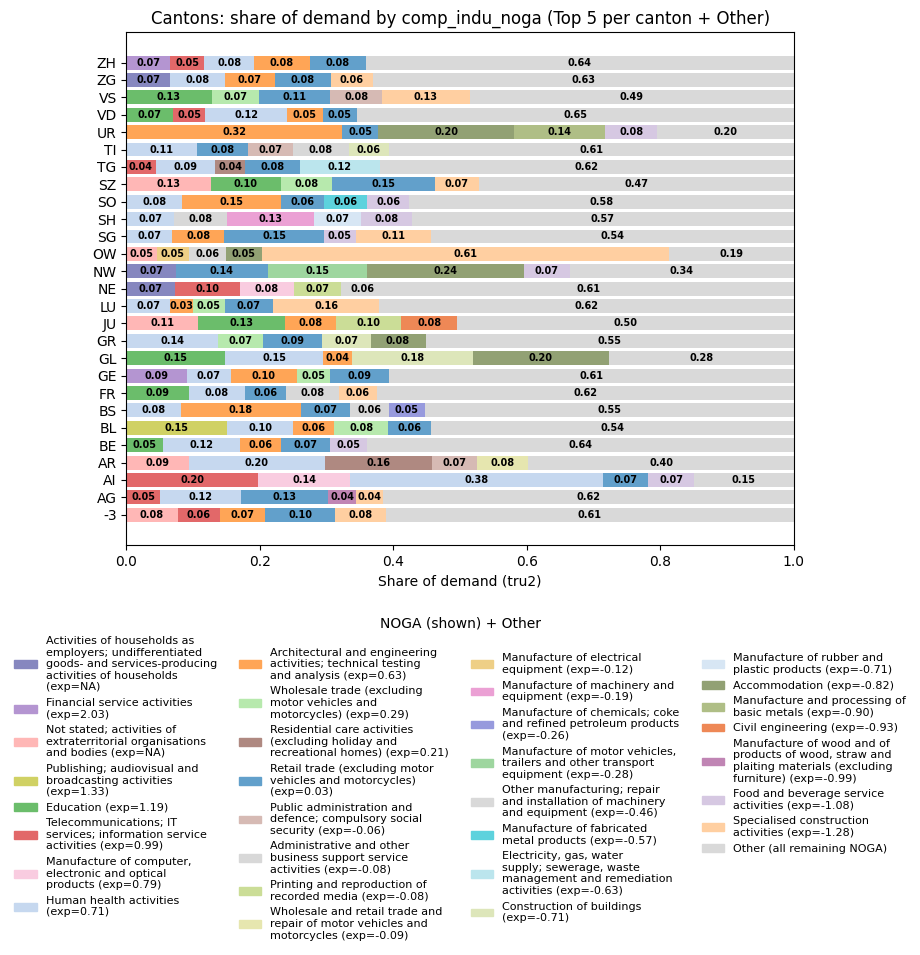

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_kanton_stack_comp_indu_noga_share.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/618135751.py:127: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


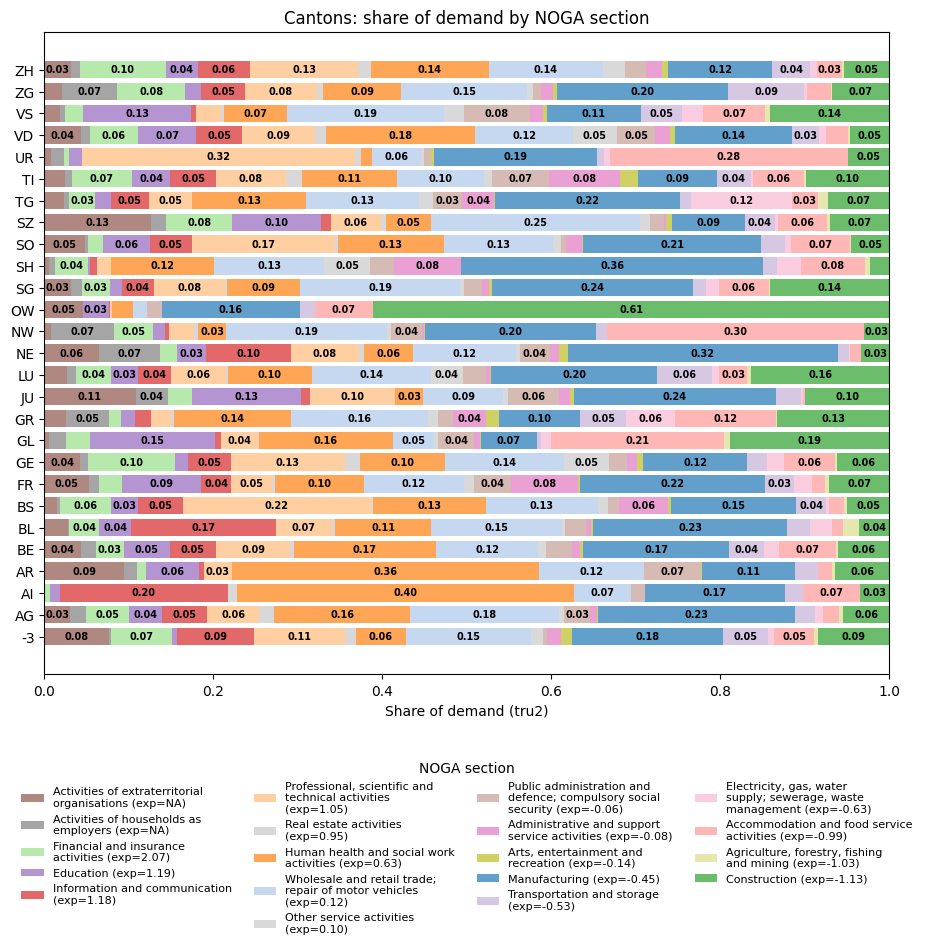

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_kanton_stack_section_share.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/618135751.py:181: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


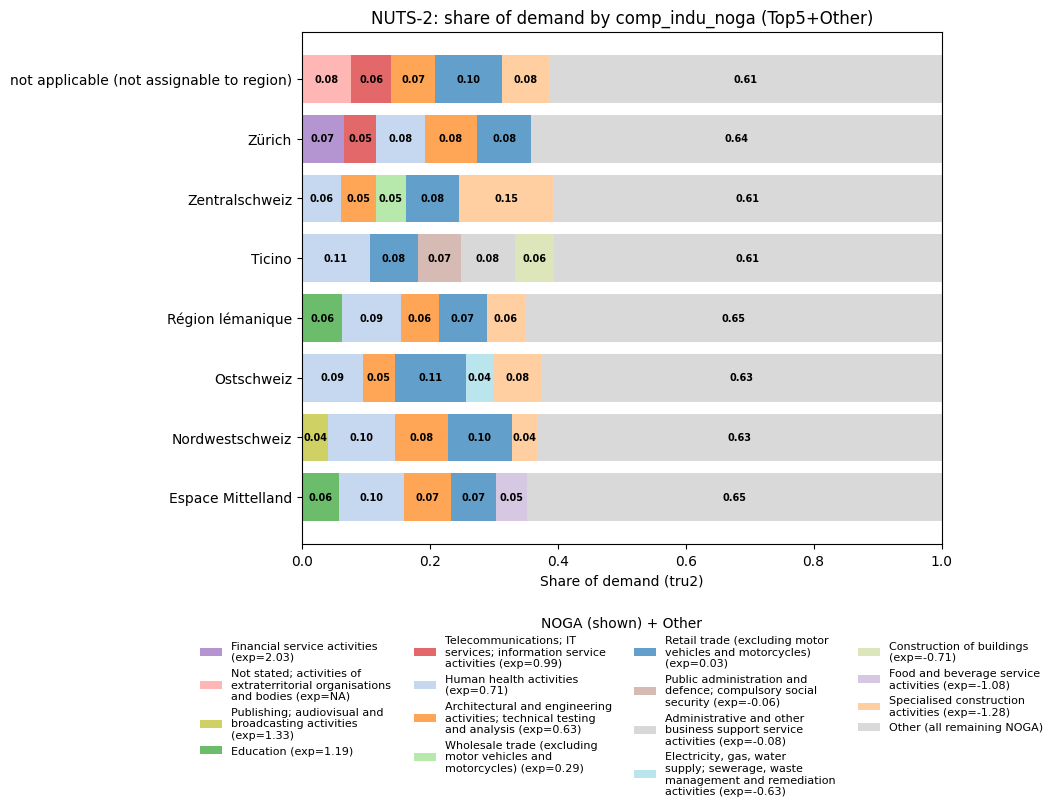

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_nuts-2_stack_comp_indu_noga_share.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/618135751.py:236: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


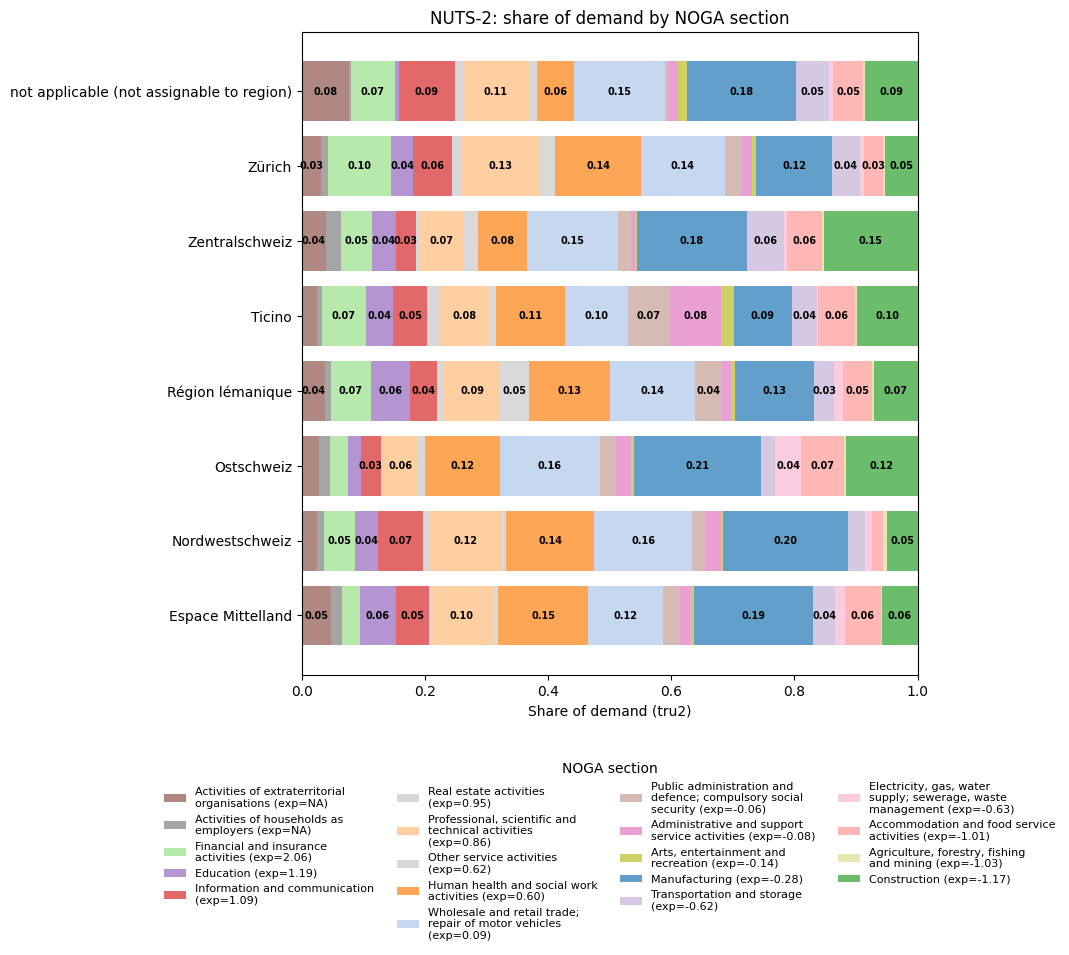

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_nuts-2_stack_section_share.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/618135751.py:181: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


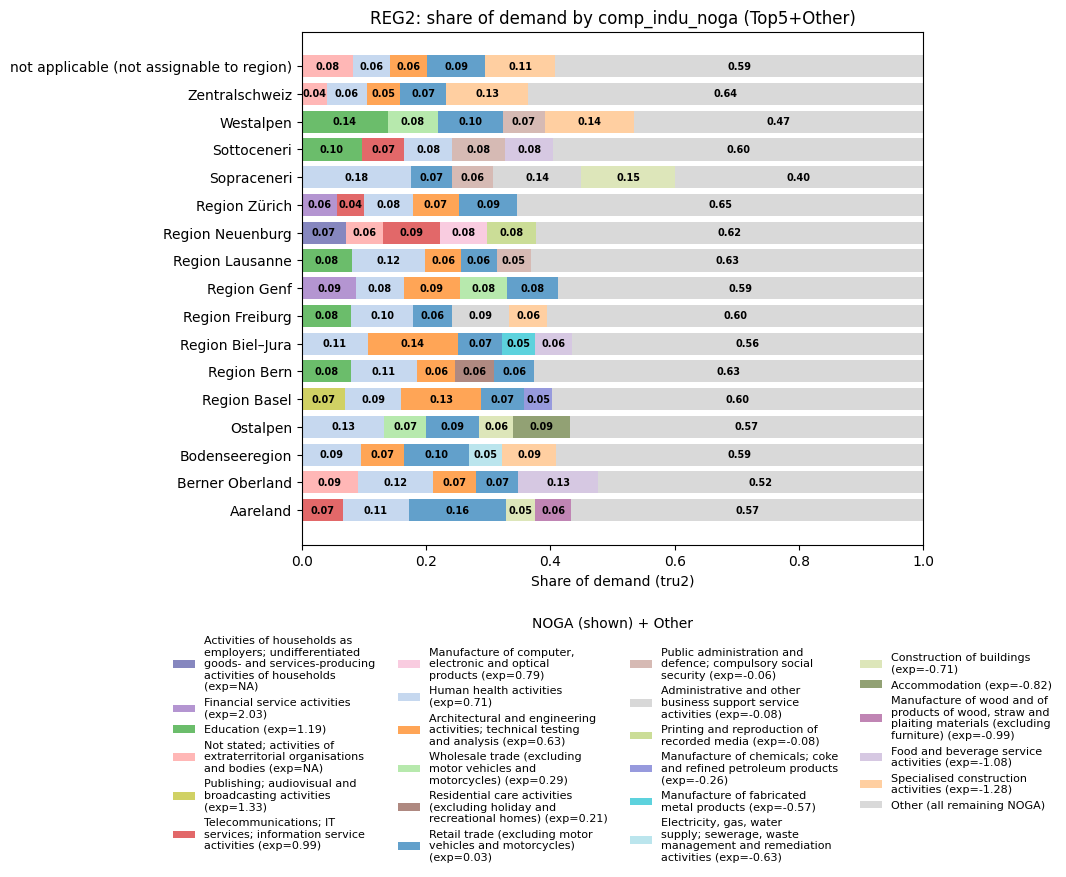

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_reg2_stack_comp_indu_noga_share.png


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/618135751.py:236: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


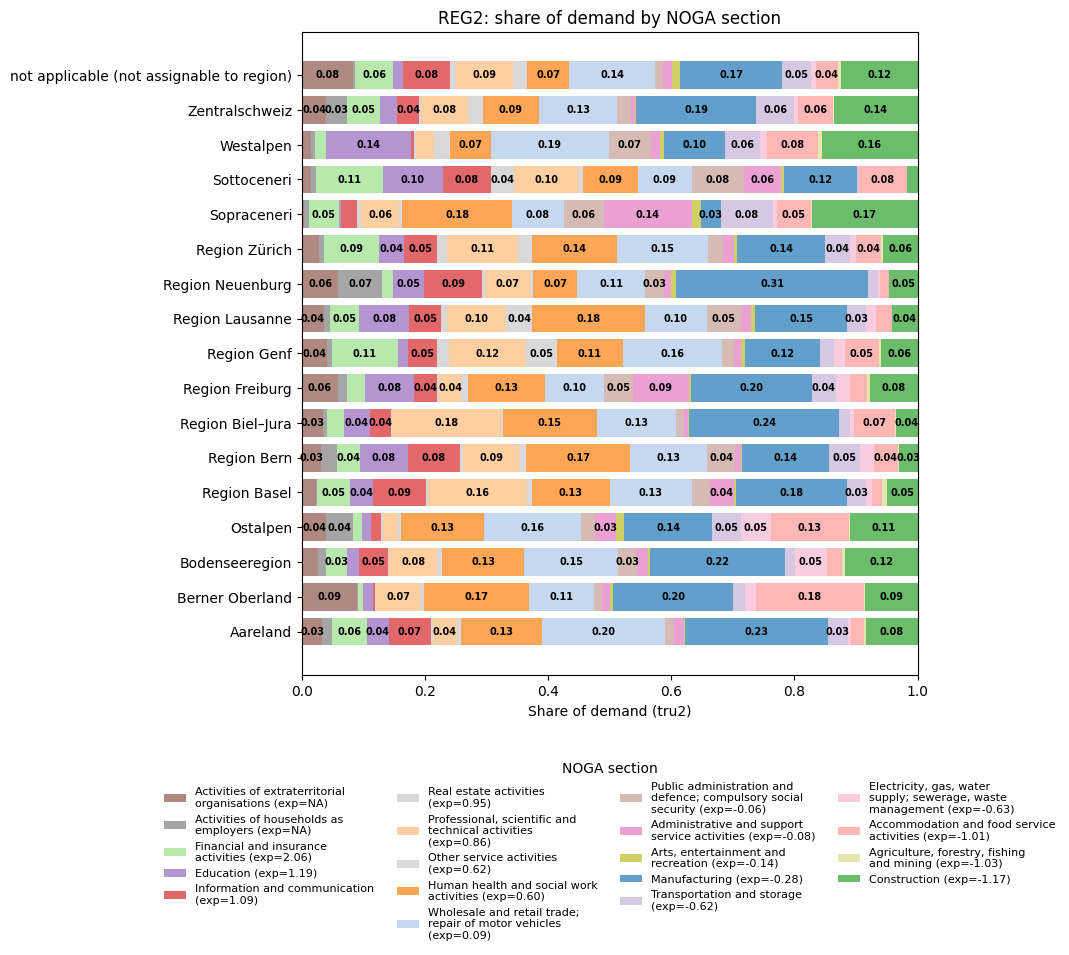

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_reg2_stack_section_share.png


In [61]:
# === Industry: shares by canton (comp_indu_noga + NOGA section) ===
import textwrap
from matplotlib.patches import Patch
import re


def _wrap_labels(labels, width=30):
    return [textwrap.fill(str(l), width=width) for l in labels]


def _exp_from_label(lbl):
    m = re.search(r"exp=([+-]?\d*\.?\d+)", str(lbl))
    return float(m.group(1)) if m else float("nan")


def _legend_below(ax, handles=None, labels=None, title=None, ncol=4):
    if handles is None or labels is None:
        handles, labels = ax.get_legend_handles_labels()
    labels = _wrap_labels(labels, width=30)
    leg = ax.legend(handles, labels, title=title, ncol=ncol,
                    loc="upper center", bbox_to_anchor=(0.5, -0.12),
                    frameon=False, fontsize=8)
    return leg

# --- Plot: share of demand by comp_indu_noga (Top 5 per canton + Other) ---
comp_label = _df["comp_indu_noga_label"].fillna("Unknown").astype(str)

comp_exp_map = (
    _df.assign(_comp=comp_label)
       .groupby("_comp", observed=True)
       .apply(lambda g: np.average(
           g.loc[g[ind_exp_col].notna(), ind_exp_col],
           weights=g.loc[g[ind_exp_col].notna(), "srvy_wght_tru2"]
       ) if g[ind_exp_col].notna().any() else np.nan)
)

comp_label_exp = comp_label.map(
    lambda lab: f"{lab} (exp={comp_exp_map.get(lab, float('nan')):.2f})"
    if pd.notna(comp_exp_map.get(lab, np.nan)) else f"{lab} (exp=NA)"
)

comp_demand = (
    _df[_df[region_col].notna()]
      .assign(_comp_label=comp_label, _comp_label_exp=comp_label_exp)
      .groupby([region_col, "_comp_label", "_comp_label_exp"], observed=True)["srvy_wght_tru2"].sum()
      .reset_index()
)

canton_totals = comp_demand.groupby(region_col)["srvy_wght_tru2"].sum().rename("total").reset_index()
comp_demand = comp_demand.merge(canton_totals, on=region_col, how="left")
comp_demand["share"] = comp_demand["srvy_wght_tru2"] / comp_demand["total"]

comp_demand["rank"] = comp_demand.groupby(region_col)["share"].rank(method="first", ascending=False)
comp_top = comp_demand[comp_demand["rank"] <= 5].copy()

comp_pivot = comp_top.pivot_table(index=region_col, columns="_comp_label_exp", values="share", fill_value=0)

other_share = comp_demand[comp_demand["rank"] > 5].groupby(region_col)["share"].sum()
comp_pivot["Other (all remaining NOGA)"] = other_share
comp_pivot = comp_pivot.fillna(0)

fig, ax = plt.subplots(figsize=(9, 10))
category_cols = comp_pivot.columns.tolist()
other_col = "Other (all remaining NOGA)"
shown_cols = [c for c in category_cols if c != other_col]
shown_cols = sorted(shown_cols, key=_exp_from_label, reverse=True)
category_cols = shown_cols + ([other_col] if other_col in category_cols else [])
comp_pivot = comp_pivot[category_cols]
shown_cols = [c for c in category_cols if c != other_col]

colors = [color_for_label(cat, color_map_comp_noga) for cat in category_cols]

bottom = np.zeros(len(comp_pivot))
y_labels = comp_pivot.index.astype(str)

for col, color in zip(category_cols, colors):
    vals = comp_pivot[col].values
    bars = ax.barh(
        y_labels,
        vals,
        left=bottom,
        height=0.8,
        color=color,
        label=col
    )
    for j, (bar, share) in enumerate(zip(bars, vals)):
        if np.isfinite(share) and share >= 0.03:
            ax.text(
                bottom[j] + share/2,
                bar.get_y() + bar.get_height()/2,
                f"{share:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=7,
                fontweight="bold"
            )
    bottom += vals

ax.set_xlabel("Share of demand (tru2)")
ax.set_title("Cantons: share of demand by comp_indu_noga (Top 5 per canton + Other)")
ax.set_xlim(0, 1)

legend_handles = []
legend_labels = []
for col in shown_cols:
    legend_handles.append(Patch(color=color_for_label(col, color_map_comp_noga)))
    legend_labels.append(col)
legend_handles.append(Patch(color=color_for_label(other_col, color_map_comp_noga)))
legend_labels.append("Other (all remaining NOGA)")
_legend_below(ax, handles=legend_handles, labels=legend_labels, title="NOGA (shown) + Other")

plt.tight_layout()
plt.subplots_adjust(bottom=0.45)
fig_path = OUT_VIS / "fig_kanton_stack_comp_indu_noga_share.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)

# --- Plot: share of demand by NOGA section (stacked bars) ---
section_exp_col = "industry_section_exposure_weighted"
section_label = _df["industry_section_label"].fillna("Unknown")

sec_exp_map = (
    _df.assign(_sec=section_label)
       .groupby("_sec", observed=True)
       .apply(lambda g: np.average(
           g.loc[g[section_exp_col].notna(), section_exp_col],
           weights=g.loc[g[section_exp_col].notna(), "srvy_wght_tru2"]
       ) if g[section_exp_col].notna().any() else np.nan)
)
section_label_exp = section_label.map(
    lambda lab: f"{lab} (exp={sec_exp_map.get(lab, float('nan')):.2f})"
    if pd.notna(sec_exp_map.get(lab, np.nan)) else f"{lab} (exp=NA)"
)

section_by_kanton = (
    _df[_df[region_col].notna()]
      .assign(_section=section_label_exp)
      .groupby([region_col, "_section"], observed=True)["srvy_wght_tru2"].sum()
      .unstack(fill_value=0)
)

section_share = section_by_kanton.div(section_by_kanton.sum(axis=1), axis=0)
section_share = section_share.loc[section_share.sum(axis=1) > 0]

fig, ax = plt.subplots(figsize=(10, 10))
labels = section_share.index.astype(str)
category_cols = section_share.columns.tolist()
category_cols = sorted(category_cols, key=_exp_from_label, reverse=True)
section_share = section_share[category_cols]
colors = [color_for_label(cat, color_map_noga_section) for cat in category_cols]

bottom = np.zeros(len(section_share))
for cat, color in zip(category_cols, colors):
    vals = section_share[cat].values
    bars = ax.barh(labels, vals, left=bottom, height=0.8, color=color, label=cat)
    for j, (bar, share) in enumerate(zip(bars, vals)):
        if np.isfinite(share) and share >= 0.03:
            ax.text(bottom[j] + share/2, bar.get_y() + bar.get_height()/2, f"{share:.2f}",
                    ha="center", va="center", color="black", fontsize=7, fontweight="bold")
    bottom += vals

ax.set_xlabel("Share of demand (tru2)")
ax.set_title("Cantons: share of demand by NOGA section")
ax.set_xlim(0, 1)
_legend_below(ax, title="NOGA section")
plt.tight_layout()
plt.subplots_adjust(bottom=0.32)
fig_path = OUT_VIS / "fig_kanton_stack_section_share.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)

# === NUTS-2 / REG2 versions of industry share plots ===
def _plot_industry_shares_by_region(region_col_override, region_label):
    comp_label = _df['comp_indu_noga_label'].fillna('Unknown').astype(str)
    comp_exp_map = (
        _df.assign(_comp=comp_label)
           .groupby('_comp', observed=True)
           .apply(lambda g: np.average(
               g.loc[g[ind_exp_col].notna(), ind_exp_col],
               weights=g.loc[g[ind_exp_col].notna(), 'srvy_wght_tru2']
           ) if g[ind_exp_col].notna().any() else np.nan)
    )
    comp_label_exp = comp_label.map(
        lambda lab: f"{lab} (exp={comp_exp_map.get(lab, float('nan')):.2f})" if pd.notna(comp_exp_map.get(lab, np.nan)) else f"{lab} (exp=NA)"
    )
    comp_demand = (
        _df[_df[region_col_override].notna()]
          .assign(_comp_label=comp_label, _comp_label_exp=comp_label_exp)
          .groupby([region_col_override, '_comp_label', '_comp_label_exp'], observed=True)['srvy_wght_tru2'].sum()
          .reset_index()
    )
    totals = comp_demand.groupby(region_col_override)['srvy_wght_tru2'].sum().rename('total').reset_index()
    comp_demand = comp_demand.merge(totals, on=region_col_override, how='left')
    comp_demand['share'] = comp_demand['srvy_wght_tru2'] / comp_demand['total']
    comp_demand['rank'] = comp_demand.groupby(region_col_override)['share'].rank(method='first', ascending=False)
    comp_top = comp_demand[comp_demand['rank'] <= 5].copy()
    comp_pivot = comp_top.pivot_table(index=region_col_override, columns='_comp_label_exp', values='share', fill_value=0)
    other = comp_demand[comp_demand['rank'] > 5].groupby(region_col_override)['share'].sum()
    comp_pivot['Other (all remaining NOGA)'] = other
    comp_pivot = comp_pivot.fillna(0)
    other_col = 'Other (all remaining NOGA)'
    shown_cols = [c for c in comp_pivot.columns if c != other_col]
    shown_cols = sorted(shown_cols, key=_exp_from_label, reverse=True)
    category_cols = shown_cols + ([other_col] if other_col in comp_pivot.columns else [])
    comp_pivot = comp_pivot[category_cols]
    fig, ax = plt.subplots(figsize=(10, 10))
    colors = [color_for_label(cat, color_map_comp_noga) for cat in category_cols]
    bottom = np.zeros(len(comp_pivot))
    for cat, color in zip(category_cols, colors):
        vals = comp_pivot[cat].values
        ax.barh(comp_pivot.index.astype(str), vals, left=bottom, height=0.8, color=color, label=cat)
        for j, share in enumerate(vals):
            if np.isfinite(share) and share >= 0.03:
                ax.text(bottom[j] + share/2, j, f"{share:.2f}", ha='center', va='center', fontsize=7, fontweight='bold', color='black')
        bottom += vals
    ax.set_xlabel('Share of demand (tru2)')
    ax.set_title(f'{region_label}: share of demand by comp_indu_noga (Top5+Other)')
    ax.set_xlim(0,1)
    _legend_below(ax, title='NOGA (shown) + Other')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.45)
    fig_path = OUT_VIS / f'fig_{region_label.lower()}_stack_comp_indu_noga_share.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)
    # NOGA section
    sec_col = 'industry_section_label' if 'industry_section_label' in _df.columns else 'noga_section_label' if 'noga_section_label' in _df.columns else None
    if sec_col:
        section_label = _df[sec_col].fillna('Unknown')
        sec_exp_map = (
            _df.assign(_sec=section_label)
               .groupby('_sec', observed=True)
               .apply(lambda g: np.average(
                   g.loc[g[ind_exp_col].notna(), ind_exp_col],
                   weights=g.loc[g[ind_exp_col].notna(), 'srvy_wght_tru2']
               ) if g[ind_exp_col].notna().any() else np.nan)
        )
        sec_label_exp = section_label.map(
            lambda lab: f"{lab} (exp={sec_exp_map.get(lab, float('nan')):.2f})" if pd.notna(sec_exp_map.get(lab, np.nan)) else f"{lab} (exp=NA)"
        )
        sec_demand = (
            _df[_df[region_col_override].notna()]
              .assign(_sec=sec_label_exp)
              .groupby([region_col_override, '_sec'], observed=True)['srvy_wght_tru2'].sum()
              .unstack(fill_value=0)
        )
        sec_share = sec_demand.div(sec_demand.sum(axis=1), axis=0)
        sec_share = sec_share.loc[sec_share.sum(axis=1) > 0]
        fig, ax = plt.subplots(figsize=(10, 10))
        cols = sorted(sec_share.columns.tolist(), key=_exp_from_label, reverse=True)
        sec_share = sec_share[cols]
        colors = [color_for_label(cat, color_map_noga_section) for cat in cols]
        bottom = np.zeros(len(sec_share))
        for cat, color in zip(cols, colors):
            vals = sec_share[cat].values
            ax.barh(sec_share.index.astype(str), vals, left=bottom, height=0.8, color=color, label=cat)
            for j, share in enumerate(vals):
                if np.isfinite(share) and share >= 0.03:
                    ax.text(bottom[j] + share/2, j, f"{share:.2f}", ha='center', va='center', fontsize=7, fontweight='bold', color='black')
            bottom += vals
        ax.set_xlabel('Share of demand (tru2)')
        ax.set_title(f'{region_label}: share of demand by NOGA section')
        ax.set_xlim(0,1)
        _legend_below(ax, title='NOGA section')
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.32)
        fig_path = OUT_VIS / f'fig_{region_label.lower()}_stack_section_share.png'
        plt.savefig(fig_path, dpi=150)
        plt.show()
        print('Saved', fig_path)

nuts_col = 'loca_regi_nuts_label' if 'loca_regi_nuts_label' in _df.columns else ('loca_regi_nuts' if 'loca_regi_nuts' in _df.columns else None)
reg2_col = 'loca_labo_reg2_label' if 'loca_labo_reg2_label' in _df.columns else ('loca_labo_reg2' if 'loca_labo_reg2' in _df.columns else None)
if nuts_col:
    _plot_industry_shares_by_region(nuts_col, 'NUTS-2')
if reg2_col:
    _plot_industry_shares_by_region(reg2_col, 'REG2')


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_37832/908158133.py:166: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = list(cm.get_cmap("tab20").colors) + list(cm.get_cmap("tab20b").colors) + list(cm.get_cmap("tab20c").colors)


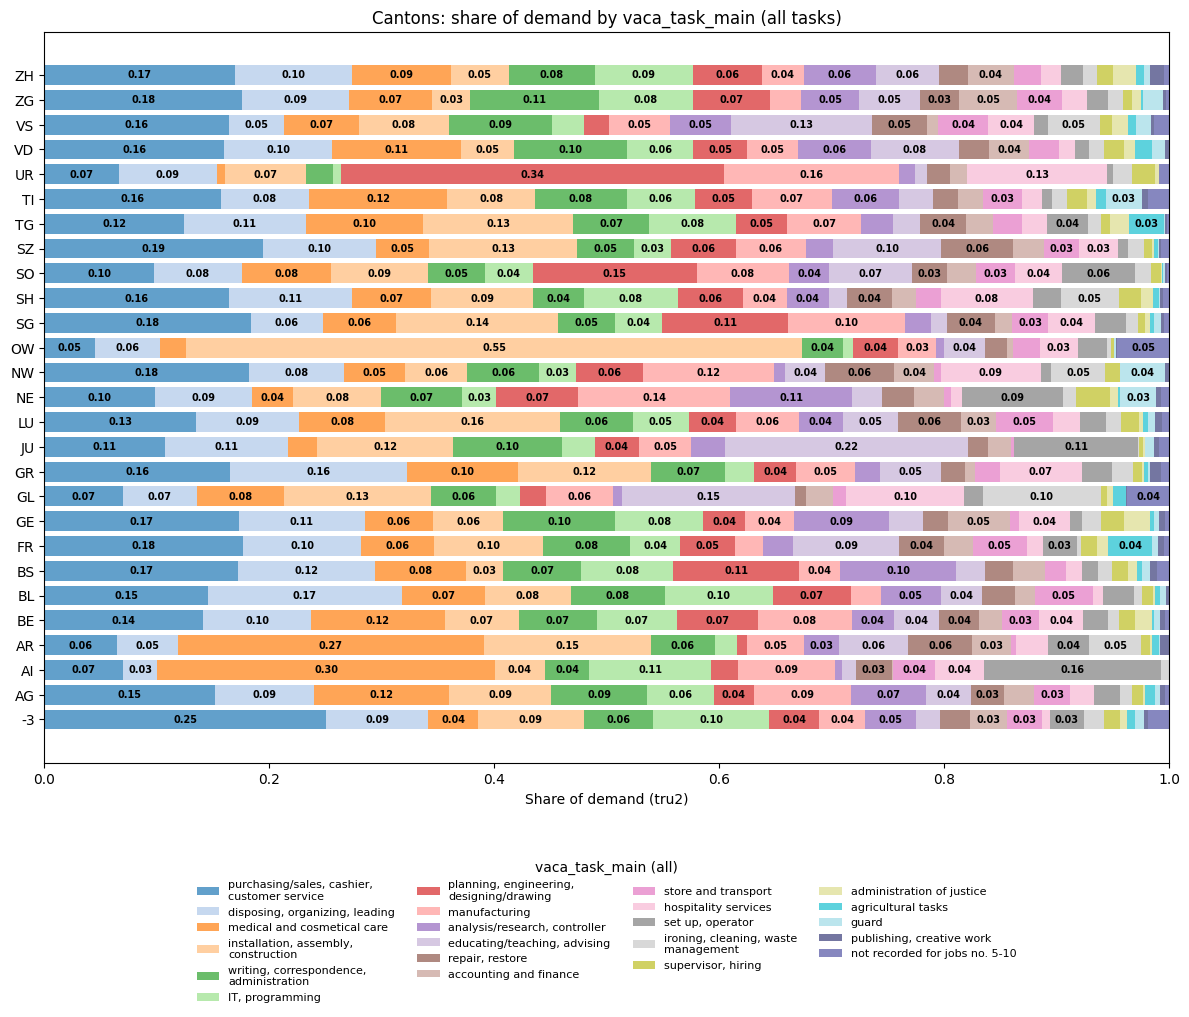

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_kanton_stack_vaca_task_main_share.png


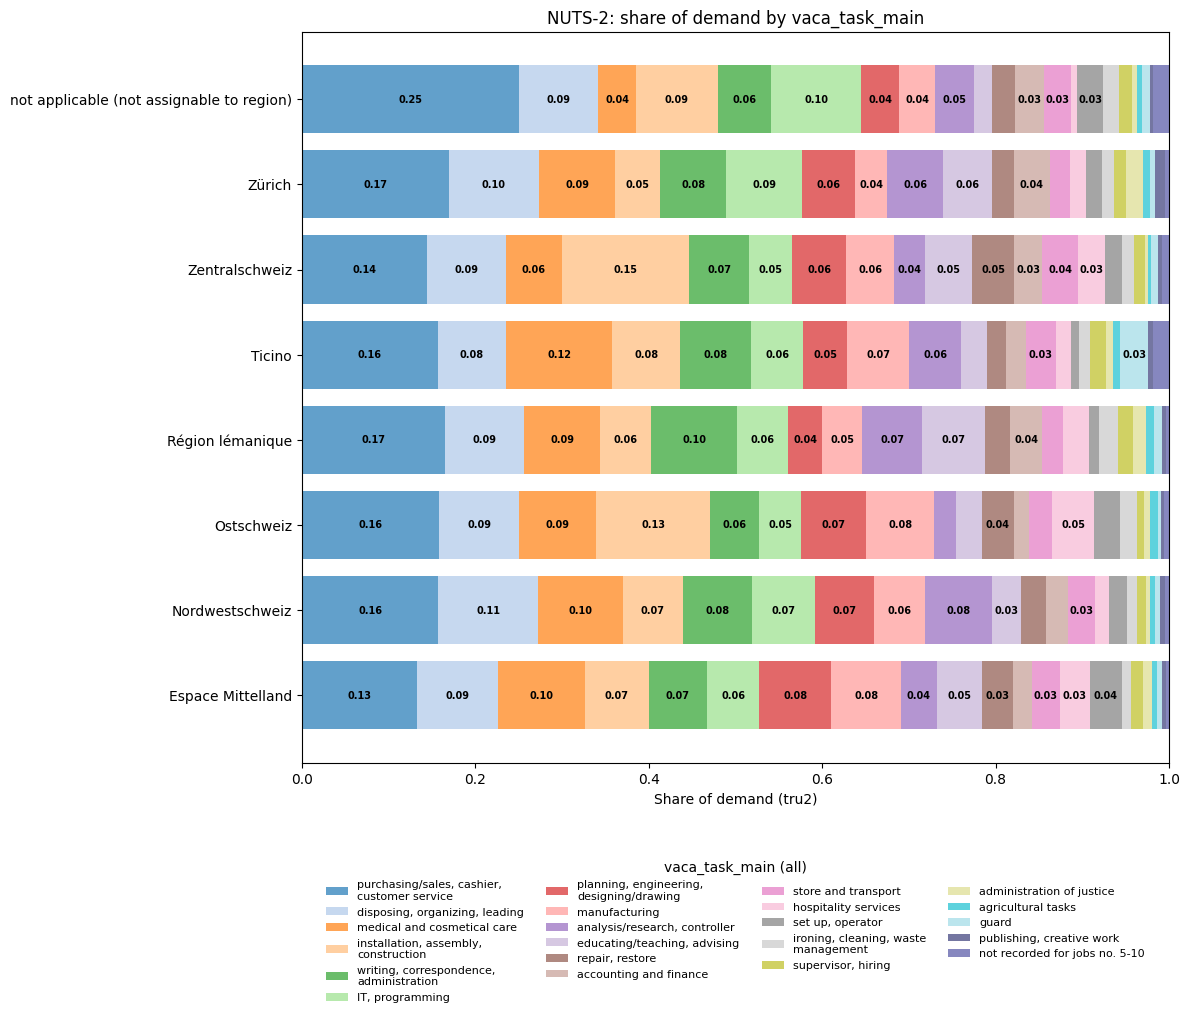

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_nuts-2_stack_vaca_task_main_share.png


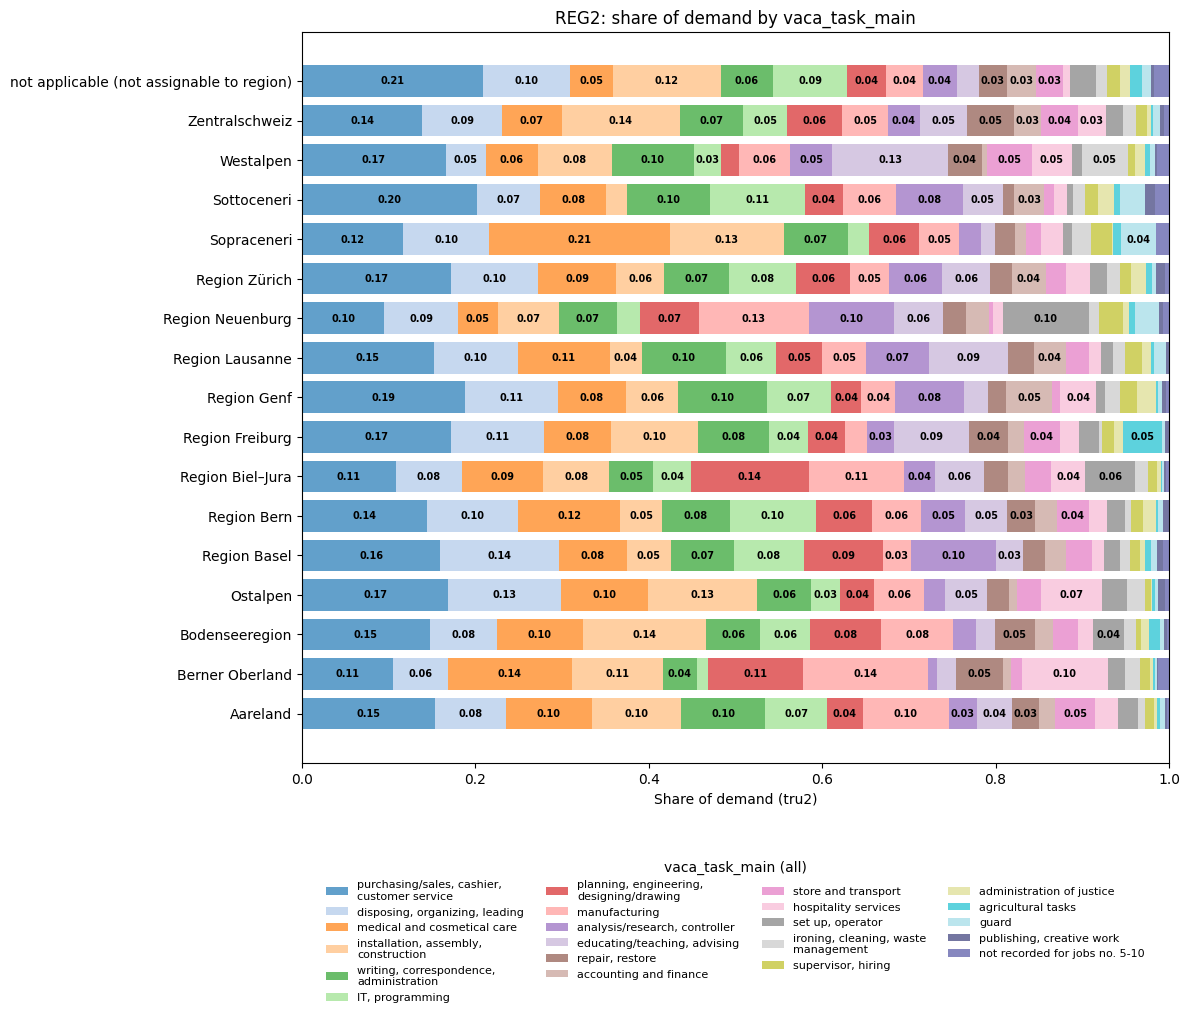

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase1_demand/visuals/fig_reg2_stack_vaca_task_main_share.png


In [62]:
# === Plot: share of demand by vaca_task_main (all tasks) ===

task_map_path = ROOT / "External datasets" / "Cross-walks" / "vaca_task_main_labels.csv"
task_map = pd.read_csv(task_map_path)
task_map["code"] = pd.to_numeric(task_map["code"], errors="coerce")
task_label_map = dict(zip(task_map["code"], task_map["label"]))

task_code = pd.to_numeric(_df["vaca_task_main"], errors="coerce")
task_label = task_code.map(task_label_map).fillna("Unknown").astype(str)

# Global ordering by tru2 share
_task_order = (
    _df.assign(_task=task_label)
      .groupby("_task")["srvy_wght_tru2"].sum().sort_values(ascending=False)
)
color_map_task = build_color_map(_ordered_labels_from_series(_task_order), other_label="Other")

# Canton shares
_task_demand = (
    _df[_df[region_col].notna()]
      .assign(_task=task_label)
      .groupby([region_col, "_task"], observed=True)["srvy_wght_tru2"].sum()
      .unstack(fill_value=0)
)
_task_share = _task_demand.div(_task_demand.sum(axis=1), axis=0)
_task_share = _task_share.loc[_task_share.sum(axis=1) > 0]

# Stable column order
category_cols = [c for c in _task_order.index if c in _task_share.columns]
missing_cols = [c for c in _task_share.columns if c not in category_cols]
category_cols += missing_cols
_task_share = _task_share[category_cols]

fig, ax = plt.subplots(figsize=(12, 12))
labels = _task_share.index.astype(str)
colors = [color_for_label(cat, color_map_task) for cat in category_cols]

bottom = np.zeros(len(_task_share))
for cat, color in zip(category_cols, colors):
    vals = _task_share[cat].values
    bars = ax.barh(labels, vals, left=bottom, height=0.8, color=color, label=cat)
    for j, (bar, share) in enumerate(zip(bars, vals)):
        if np.isfinite(share) and share >= 0.03:
            ax.text(bottom[j] + share/2, bar.get_y() + bar.get_height()/2, f"{share:.2f}",
                    ha="center", va="center", color="black", fontsize=7, fontweight="bold")
    bottom += vals

ax.set_xlabel("Share of demand (tru2)")
ax.set_title("Cantons: share of demand by vaca_task_main (all tasks)")
ax.set_xlim(0, 1)
_legend_below(ax, title="vaca_task_main (all)", ncol=4)
plt.tight_layout()
plt.subplots_adjust(bottom=0.36)
fig_path = OUT_VIS / "fig_kanton_stack_vaca_task_main_share.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)

# === NUTS-2 / REG2 versions of vaca_task_main share plot ===
def _plot_task_shares_by_region(region_col_override, region_label, task_label):
    task_demand = (
        _df[_df[region_col_override].notna()]
          .assign(_task=task_label)
          .groupby([region_col_override, '_task'], observed=True)['srvy_wght_tru2'].sum()
          .unstack(fill_value=0)
    )
    task_share = task_demand.div(task_demand.sum(axis=1), axis=0)
    task_share = task_share.loc[task_share.sum(axis=1) > 0]
    # order by national share
    order = _df.assign(_task=task_label).groupby('_task')['srvy_wght_tru2'].sum().sort_values(ascending=False).index.tolist()
    cols = [c for c in order if c in task_share.columns] + [c for c in task_share.columns if c not in order]
    task_share = task_share[cols]
    fig, ax = plt.subplots(figsize=(12, 12))
    colors = [color_for_label(cat, color_map_task) for cat in cols]
    bottom = np.zeros(len(task_share))
    for cat, color in zip(cols, colors):
        vals = task_share[cat].values
        ax.barh(task_share.index.astype(str), vals, left=bottom, height=0.8, color=color, label=cat)
        for j, share in enumerate(vals):
            if np.isfinite(share) and share >= 0.03:
                ax.text(bottom[j] + share/2, j, f"{share:.2f}", ha='center', va='center', fontsize=7, fontweight='bold', color='black')
        bottom += vals
    ax.set_xlabel('Share of demand (tru2)')
    ax.set_title(f'{region_label}: share of demand by vaca_task_main')
    ax.set_xlim(0,1)
    _legend_below(ax, title='vaca_task_main (all)', ncol=4)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.36)
    fig_path = OUT_VIS / f'fig_{region_label.lower()}_stack_vaca_task_main_share.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

nuts_col = 'loca_regi_nuts_label' if 'loca_regi_nuts_label' in _df.columns else ('loca_regi_nuts' if 'loca_regi_nuts' in _df.columns else None)
reg2_col = 'loca_labo_reg2_label' if 'loca_labo_reg2_label' in _df.columns else ('loca_labo_reg2' if 'loca_labo_reg2' in _df.columns else None)
if nuts_col:
    _plot_task_shares_by_region(nuts_col, 'NUTS-2', task_label)
if reg2_col:
    _plot_task_shares_by_region(reg2_col, 'REG2', task_label)
